In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from scipy.stats import norm, lognorm, invgauss, probplot, shapiro, kstest, zscore
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import acf, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from itertools import combinations

# Data Processing

In [13]:
# Load the dataset
file_path = "6_Portfolios_ME_OP_2x3.csv"
df = pd.read_csv(file_path)

# Load the dataset from the row where the actual data begins (row 13 in file, which is index 12)
df = pd.read_csv(file_path, skiprows=13, header=None)
df.columns = ['Date', 'SMALL LoOP', 'ME1 OP2', 'SMALL HiOP', 'BIG LoOP', 'ME2 OP2', 'BIG HiOP']
df.dropna(inplace=True)
df['Date'] = pd.to_datetime(df['Date'], format='%Y%m')
df = df.set_index('Date')


# Convert return columns to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col])

df = df.astype(float)/100

price_df = np.log1p(np.exp(np.log1p(df).cumsum())) # Log prices
# price_cum = np.log1p(df).cumsum()
# Basic statistics summary
summary_stats = df.iloc[:, :].describe()


df.to_csv("data_clean.csv", index=False)
df.head()


,SMALL LoOP,ME1 OP2,SMALL HiOP,BIG LoOP,ME2 OP2,BIG HiOP
Date,,,,,,
1963-07-01,-0.008182,-0.004613,-0.004156,-0.008456,0.003816,0.001095
1963-08-01,0.048507,0.042202,0.052868,0.055121,0.049791,0.057862
1963-09-01,-0.010166,-0.014324,-0.026991,-0.017189,-0.008015,-0.014500
1963-10-01,0.013664,0.015104,0.016166,0.008173,0.014846,0.061639
1963-11-01,-0.012569,-0.011001,-0.023721,-0.014554,0.002942,-0.013506


In [14]:
price_df.head()

,SMALL LoOP,ME1 OP2,SMALL HiOP,BIG LoOP,ME2 OP2,BIG HiOP
Date,,,,,,
1963-07-01,0.689048,0.690838,0.691067,0.688910,0.695053,0.693695
1963-08-01,0.712915,0.711672,0.717104,0.715984,0.719690,0.722230
1963-09-01,0.707719,0.704352,0.703193,0.707156,0.715569,0.714745
1963-10-01,0.714626,0.711959,0.711323,0.711291,0.723128,0.745737
1963-11-01,0.708187,0.706340,0.699176,0.703856,0.724642,0.738613


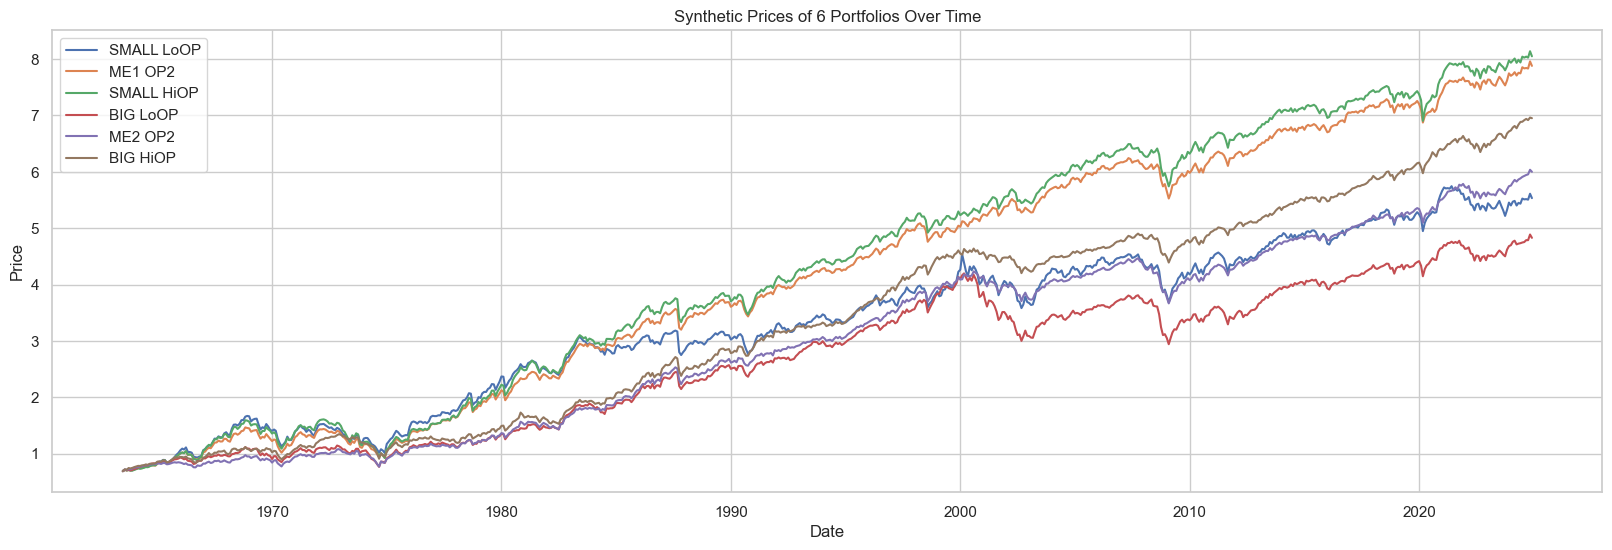

In [15]:
# price_df.set_index('Date', inplace=True)
# df.set_index('Date', inplace=True)


plt.figure(figsize=(20,6))

for column in price_df.columns:  # Using columns directly
    plt.plot(price_df.index, price_df[column], label=column)

plt.title('Synthetic Prices of 6 Portfolios Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.legend()

In [16]:
summary_stats = df.iloc[:, :].describe()
print(summary_stats)


       SMALL LoOP     ME1 OP2  SMALL HiOP    BIG LoOP     ME2 OP2    BIG HiOP
count  738.000000  738.000000  738.000000  738.000000  738.000000  738.000000
mean     0.009717    0.012203    0.012884    0.007897    0.009117    0.010428
std      0.065976    0.053913    0.061421    0.051445    0.043634    0.043858
min     -0.320418   -0.277835   -0.306991   -0.236169   -0.202954   -0.218480
25%     -0.026431   -0.017796   -0.023559   -0.018757   -0.015081   -0.015567
50%      0.013020    0.014710    0.016802    0.011624    0.012031    0.012261
75%      0.049108    0.045175    0.048707    0.040330    0.034960    0.039306
max      0.309955    0.260254    0.277177    0.177440    0.182104    0.170828


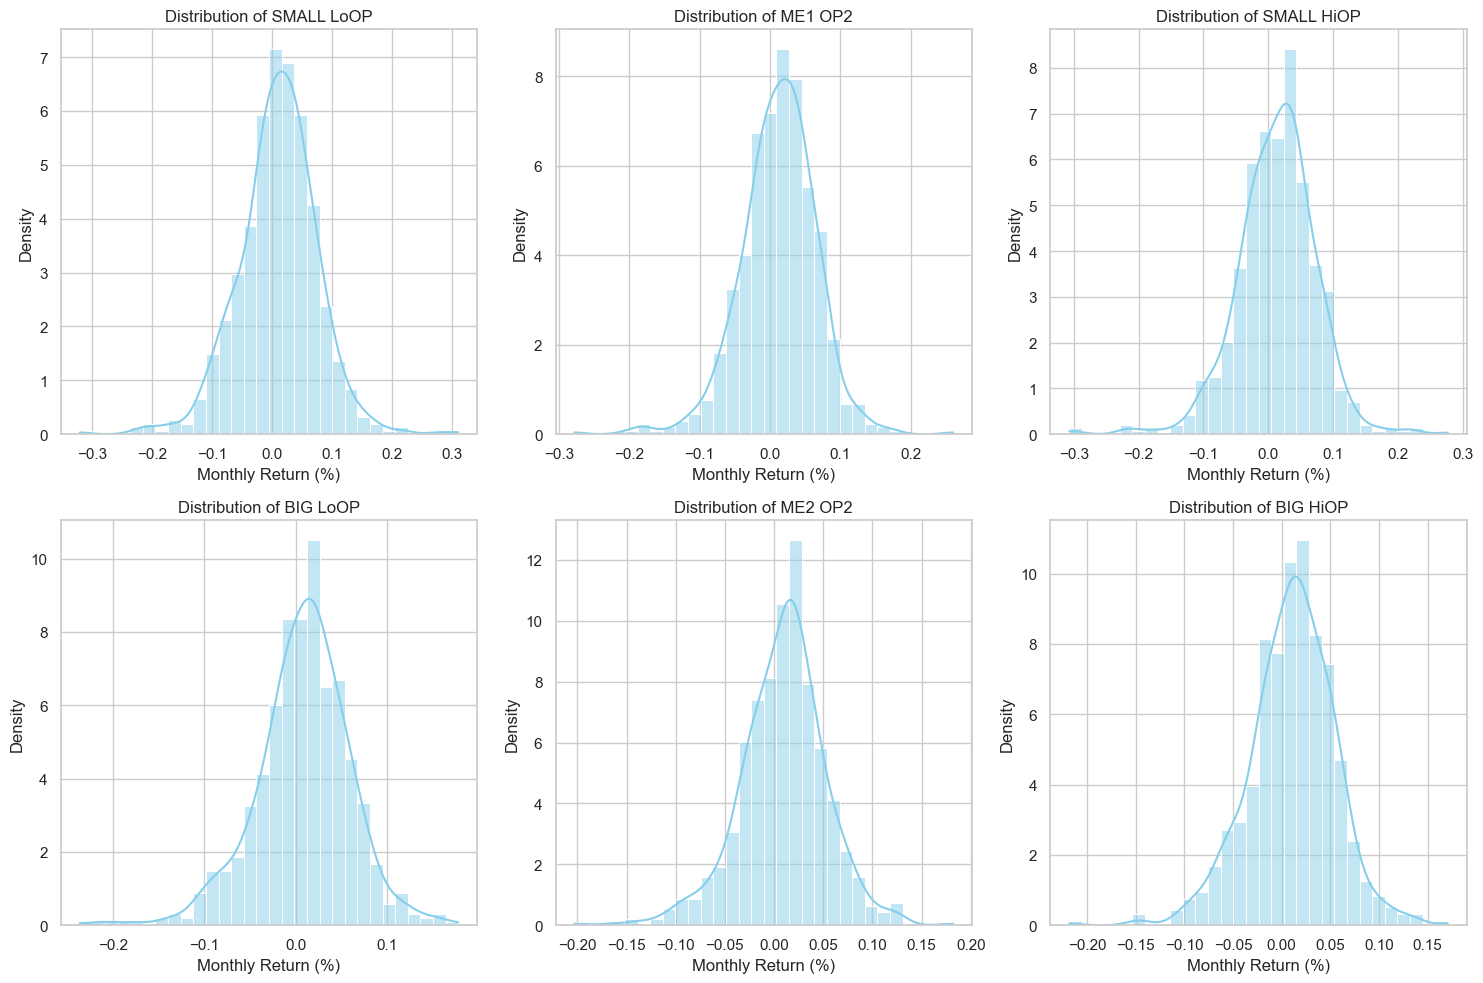

In [17]:
# Set up the plotting style for better clarity
sns.set(style="whitegrid")

# Define a function to plot histograms and KDEs for each portfolio
def plot_distribution(df, portfolios):
    plt.figure(figsize=(15, 10))
    for i, portfolio in enumerate(portfolios, 1):
        plt.subplot(2, 3, i)
        sns.histplot(df[portfolio], kde=True, bins=30, color='skyblue', stat="density")
        plt.title(f'Distribution of {portfolio}')
        plt.xlabel('Monthly Return (%)')
        plt.ylabel('Density')
    plt.tight_layout()
    plt.show()

# List of portfolio columns
portfolios = ['SMALL LoOP', 'ME1 OP2', 'SMALL HiOP', 'BIG LoOP', 'ME2 OP2', 'BIG HiOP']

# Plot distributions for each portfolio
plot_distribution(df, portfolios)

# Test against normal distribution

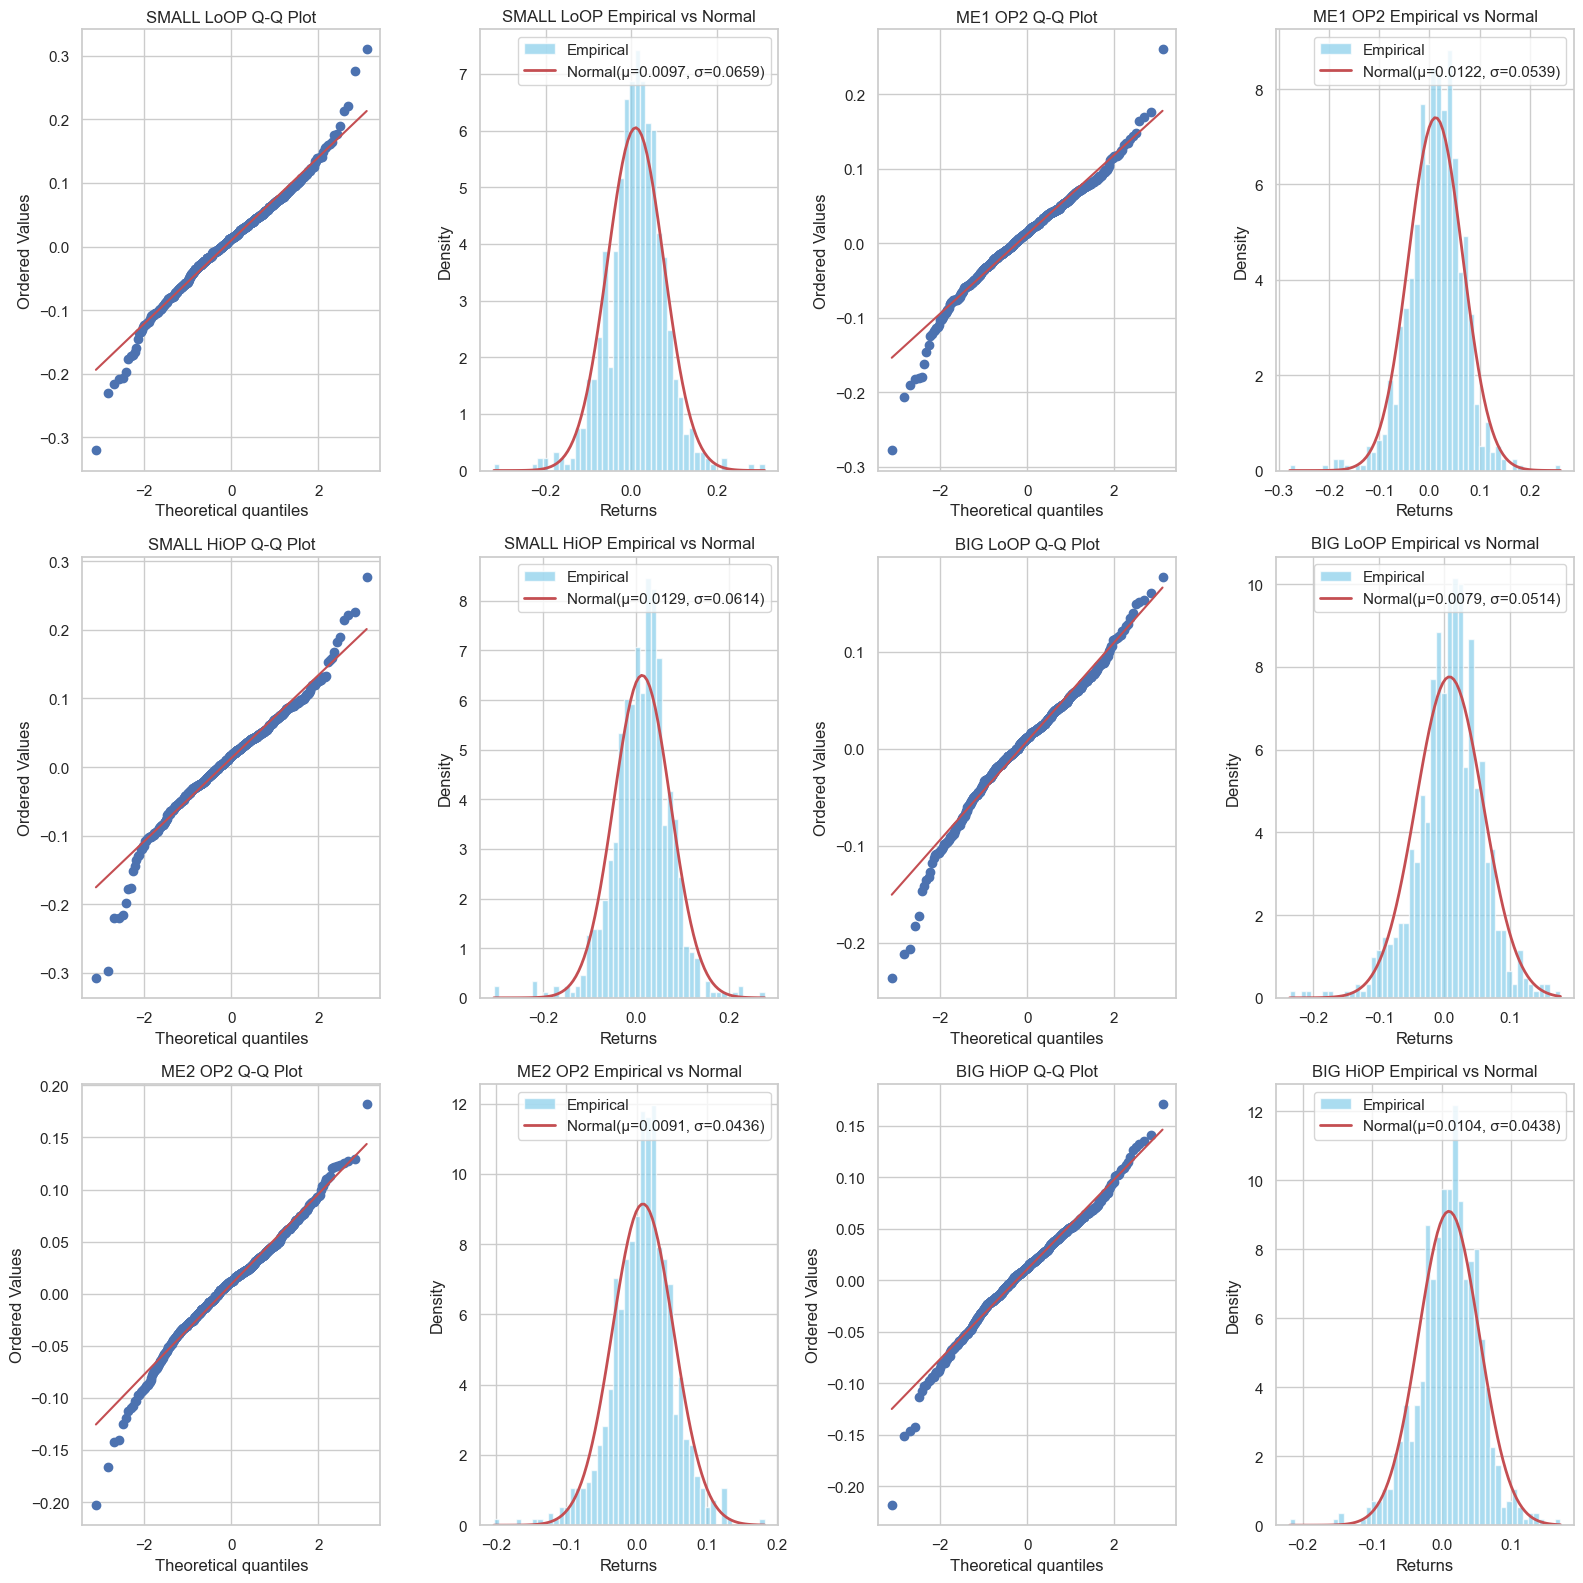

In [18]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 16))

# Iterate through each portfolio
for idx, portfolio in enumerate(portfolios):
    # Remove missing data and fit normal distribution to the data
    portfolio_data = df[portfolio].dropna()
    mean, std_dev = norm.fit(portfolio_data)

    # Calculate the position of the subplot in the 3x4 grid
    row_pos = idx // 2
    col_pos = (idx % 2) * 2  # Create pairs of plots side by side

    # Plot Q-Q plot
    probplot(portfolio_data, dist='norm', plot=axes[row_pos, col_pos])
    axes[row_pos, col_pos].set_title(f'{portfolio} Q-Q Plot')

    # Create histogram and fit normal distribution
    x_vals = np.linspace(portfolio_data.min(), portfolio_data.max(), 100)
    axes[row_pos, col_pos + 1].hist(portfolio_data, bins=50, density=True, alpha=0.7, color='skyblue', label='Empirical')
    axes[row_pos, col_pos + 1].plot(x_vals, norm.pdf(x_vals, mean, std_dev), 'r-', lw=2, label=f'Normal(μ={mean:.4f}, σ={std_dev:.4f})')
    axes[row_pos, col_pos + 1].set_title(f'{portfolio} Empirical vs Normal')
    axes[row_pos, col_pos + 1].set_xlabel('Returns')
    axes[row_pos, col_pos + 1].set_ylabel('Density')
    axes[row_pos, col_pos + 1].legend()

# Adjust layout for better visualization
plt.tight_layout()
plt.show()


In [19]:
# Define a function to fit Normal and Normal Inverse Gaussian distributions and test for normality
results = {}
for portfolio in portfolios:
    data = df[portfolio].dropna()
        
    params_norm = norm.fit(data)  # Normal distribution parameters
    n = len(data)
    log_likelihood_norm = np.sum(norm.logpdf(data, *params_norm))

    aic_norm = 2 * len(params_norm) - 2 * log_likelihood_norm
    bic_norm = len(params_norm) * np.log(n) - 2 * log_likelihood_norm

            # Shapiro-Wilk test for normality
    shapiro_stat, shapiro_p = stats.shapiro(data)

    results[portfolio] = {
        'AIC': {'Normal': aic_norm},
        'BIC': {'Normal': bic_norm},
        'Shapiro-Wilk p-value': shapiro_p
        }

# Get the results for each portfolio
# results = fit_and_test_alternate_distributions(df, portfolios)

# Organize the results in a list of dictionaries for better clarity
organized_results = []

for portfolio, result in results.items():
    organized_results.append({
        'Portfolio': portfolio,
        'AIC (Normal)': result['AIC']['Normal'],
        'BIC (Normal)': result['BIC']['Normal'],
        'Shapiro-Wilk p-value': result['Shapiro-Wilk p-value']
    })

# Convert the results to a pandas DataFrame for easier visualization
df_results = pd.DataFrame(organized_results)
df_results


,Portfolio,AIC (Normal),BIC (Normal),Shapiro-Wilk p-value
0,SMALL LoOP,-1915.098120,-1905.890233,1.471629e-08
1,ME1 OP2,-2213.131196,-2203.923308,2.818389e-10
2,SMALL HiOP,-2020.703526,-2011.495638,7.675274e-12
3,BIG LoOP,-2282.295757,-2273.087869,1.405234e-09
4,ME2 OP2,-2525.369368,-2516.161481,4.259176e-08
5,BIG HiOP,-2517.794601,-2508.586714,5.825818e-07


# Test against other distributions

In [20]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import laplace, t, norm, norminvgauss
from sklearn.preprocessing import StandardScaler

# Define a function for the Kolmogorov-Smirnov test
def ks_test_for_distribution(data, distribution):
    """
    Perform Kolmogorov-Smirnov test for a given distribution.
    Returns the KS statistic and p-value.
    """
    # Standardize data for t-distribution
    standardized_data = StandardScaler().fit_transform(data.values.reshape(-1, 1)).flatten()
    
    # Fit the distribution and perform the KS test
    if distribution == 'laplace':
        # Laplace distribution: loc=mean, scale=std
        loc, scale = laplace.fit(data)
        ks_stat, p_value = stats.ks_2samp(data, laplace.rvs(loc=loc, scale=scale, size=len(data)))
    elif distribution == 'nig':
        # Fit the Normal Inverse Gaussian (NIG) distribution
        alpha, beta, loc, scale = norminvgauss.fit(standardized_data)
        ks_stat, p_value = stats.ks_2samp(data, norminvgauss.rvs(alpha, beta, loc, scale, size=len(data)))
    elif distribution == 'student_t':
        # Fit the Student t-distribution
        df, loc, scale = t.fit(standardized_data)
        ks_stat, p_value = stats.ks_2samp(data, t.rvs(df, loc=loc, scale=scale, size=len(data)))
    elif distribution == 'normal':
        # Fit the Normal distribution
        mean, std = norm.fit(standardized_data)
        ks_stat, p_value = stats.ks_2samp(data, norm.rvs(loc=mean, scale=std, size=len(data)))
    
    return ks_stat, p_value

# Create a table to store the results
ks_results = []

# Iterate over each portfolio and apply the KS test for each distribution
for portfolio in df.columns:
    portfolio_data = df[portfolio]
    ks_laplace = ks_test_for_distribution(portfolio_data, 'laplace')
    ks_nig = ks_test_for_distribution(portfolio_data, 'nig')
    ks_student_t = ks_test_for_distribution(portfolio_data, 'student_t')
    ks_normal = ks_test_for_distribution(portfolio_data, 'normal')  # Add normal distribution test
    
    ks_results.append({
        'Portfolio': portfolio,
        'KS Statistic (Laplace)': ks_laplace[0],
        'p-value (Laplace)': ks_laplace[1],
        'KS Statistic (NIG)': ks_nig[0],
        'p-value (NIG)': ks_nig[1],
        'KS Statistic (Student t)': ks_student_t[0],
        'p-value (Student t)': ks_student_t[1],
        'KS Statistic (Normal)': ks_normal[0],  # Add result for Normal distribution
        'p-value (Normal)': ks_normal[1]       # Add p-value for Normal distribution
    })

# Convert the results to a DataFrame
ks_df = pd.DataFrame(ks_results)

ks_df

# Display the results
# import ace_tools as tools; tools.display_dataframe_to_user(name="Kolmogorov-Smirnov Test Results", dataframe=ks_df)


,Portfolio,KS Statistic (Laplace),p-value (Laplace),KS Statistic (NIG),p-value (NIG),KS Statistic (Student t),p-value (Student t),KS Statistic (Normal),p-value (Normal)
0,SMALL LoOP,0.050136,0.311863,0.433604,1.096227e-62,0.452575,1.799209e-68,0.433604,1.096227e-62
1,ME1 OP2,0.063686,0.100239,0.453930,6.774283e-69,0.483740,1.315833e-78,0.455285,2.541933e-69
2,SMALL HiOP,0.050136,0.311863,0.456640,9.505646e-70,0.434959,4.326940e-63,0.448509,3.302739e-67
3,BIG LoOP,0.077236,0.024461,0.445799,2.259642e-66,0.447154,8.653499e-67,0.444444,5.880582e-66
4,ME2 OP2,0.037940,0.663245,0.472900,5.435622e-75,0.456640,9.505646e-70,0.456640,9.505646e-70
5,BIG HiOP,0.059621,0.145103,0.466125,8.830390e-73,0.440379,1.015733e-64,0.470190,4.207918e-74


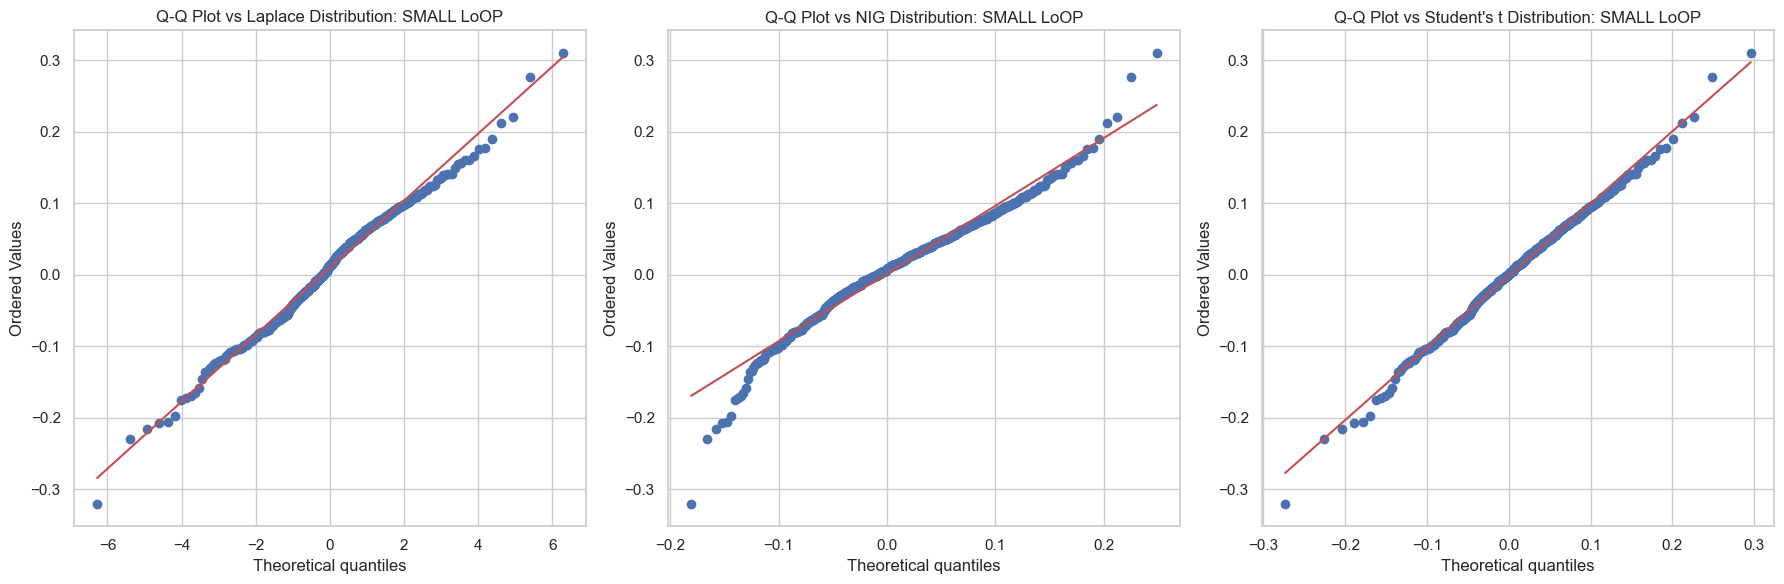

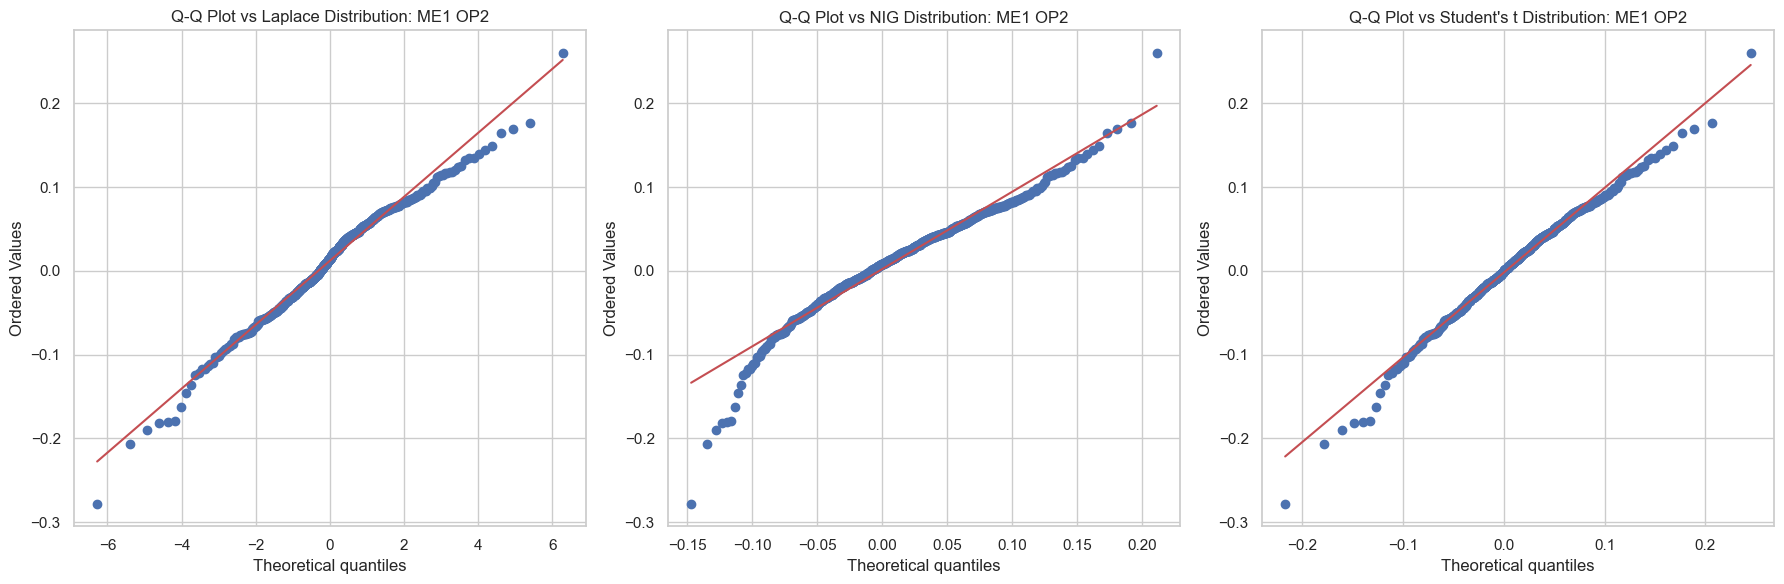

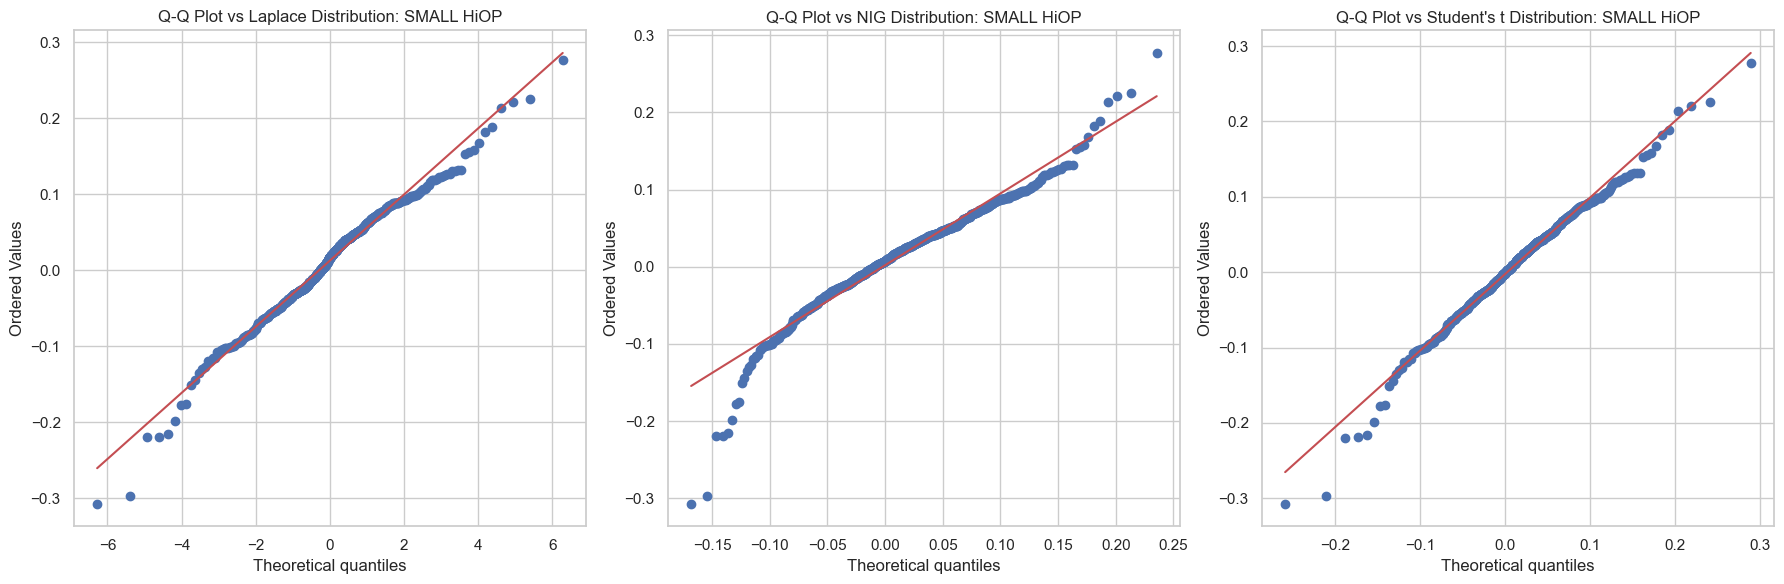

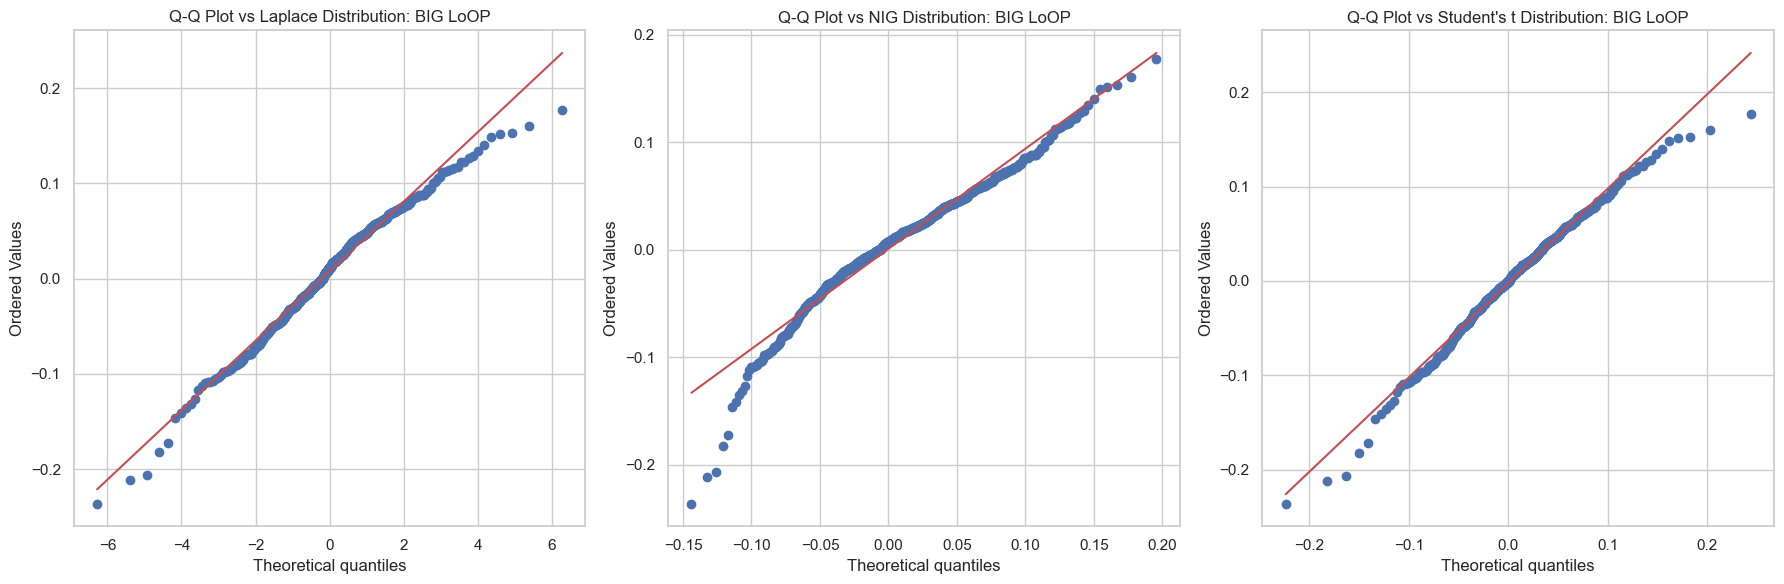

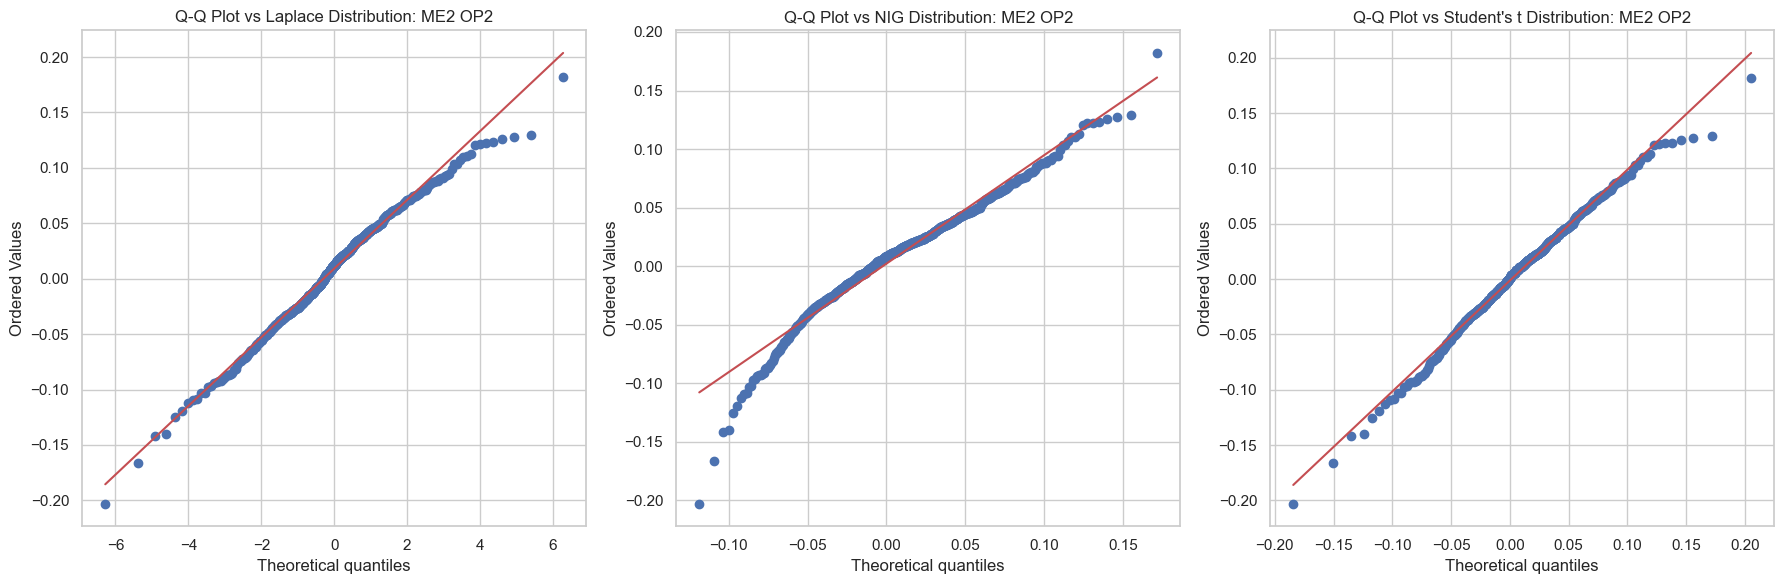

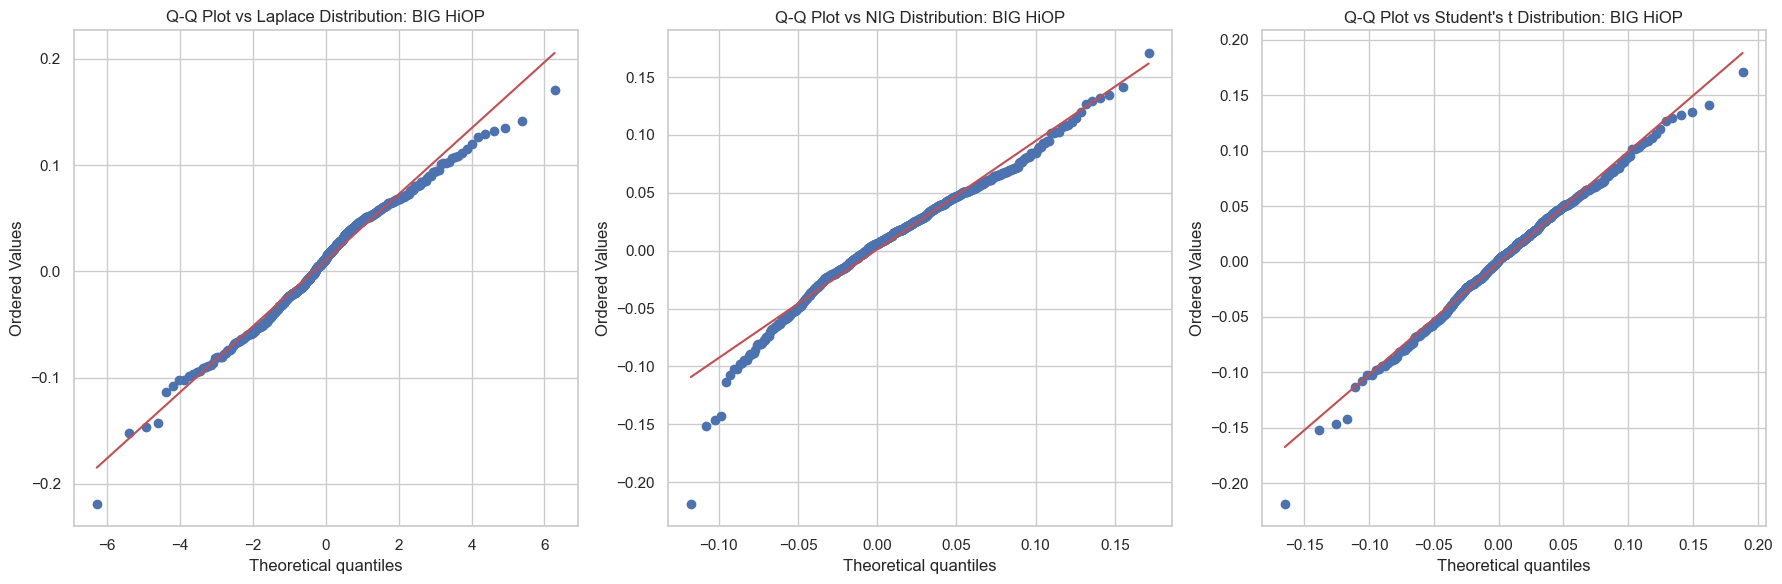

In [21]:
def plot_qq_vs_distributions(df, portfolio):
    data = df[portfolio].dropna()
    
    # Parameters for the normal distribution fit
    mu_norm, std_norm = norm.fit(data)
    
    # Parameters for the NIG distribution fit
    params_nig = invgauss.fit(data)
    
    # Parameters for the Student's t distribution fit
    params_t = t.fit(data)
    
    # Create a figure with 3 subplots for the three distributions
    plt.figure(figsize=(18, 6))

    # Q-Q Plot for Laplace distribution
    plt.subplot(1, 3, 1)
    stats.probplot(data, dist="laplace", plot=plt)
    plt.title(f'Q-Q Plot vs Laplace Distribution: {portfolio}')

    # Q-Q Plot for Normal Inverse Gaussian distribution
    plt.subplot(1, 3, 2)
    stats.probplot(data, dist=invgauss, sparams=params_nig, plot=plt)
    plt.title(f'Q-Q Plot vs NIG Distribution: {portfolio}')

    # Q-Q Plot for Student's t-distribution
    plt.subplot(1, 3, 3)
    stats.probplot(data, dist=t, sparams=params_t, plot=plt)
    plt.title(f'Q-Q Plot vs Student\'s t Distribution: {portfolio}')

    plt.tight_layout()
    plt.show()

# Plot Q-Q plots for each portfolio against Laplace, NIG, and Student's t distributions
for portfolio in portfolios:
    plot_qq_vs_distributions(df, portfolio)

# Time Series Modelling

### ARMA

In [136]:
from statsmodels.tsa.stattools import adfuller

# Function to perform the Augmented Dickey-Fuller (ADF) test for stationarity
def adf_test(df, portfolios):
    adf_results = {}
    for portfolio in portfolios:
        data = df[portfolio].dropna()
        adf_stat, p_value, _, _, _, _ = adfuller(data)
        adf_results[portfolio] = {
            'ADF Statistic': adf_stat,
            'p-value': p_value,
            'Stationary': p_value < 0.05  # If p-value < 0.05, the series is stationary
        }
    return adf_results

# Perform the ADF test for all portfolios
adf_results = adf_test(df, portfolios)

# Display the results
adf_results = pd.DataFrame(adf_results)

adf_results


,SMALL LoOP,ME1 OP2,SMALL HiOP,BIG LoOP,ME2 OP2,BIG HiOP
ADF Statistic,-18.945695,-19.169683,-24.240631,-25.633129,-10.698363,-26.584941
p-value,0.0,0.0,0.0,0.0,0.0,0.0
Stationary,True,True,True,True,True,True


In [22]:
import warnings
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings('ignore')
# Extracting the first portfolio data for modeling
portfolio_1 = df['SMALL LoOP'] 

# We'll try different p and q values (ARMA(p, q)) and calculate AIC and BIC to find the best model
best_aic = float('inf')
best_bic = float('inf')
best_order = None
best_model = None

# Trying different combinations of p and q from 0 to 5
for p in range(6):
    for q in range(6):
        try:
            model = ARIMA(portfolio_1, order=(p, 0, q))  # ARMA model (p, 0, q) since we don't need differencing here
            results = model.fit()
            
            # Update the best model based on AIC
            if results.aic < best_aic:
                best_aic = results.aic
                best_bic = results.bic
                best_order = (p, q)
                best_model = results
        except:
            continue

print(best_model.summary())

                               SARIMAX Results                                
Dep. Variable:             SMALL LoOP   No. Observations:                  738
Model:                 ARIMA(1, 0, 2)   Log Likelihood                 969.107
Date:                Sun, 11 May 2025   AIC                          -1928.213
Time:                        21:12:15   BIC                          -1905.194
Sample:                    07-01-1963   HQIC                         -1919.337
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0095      0.001     10.036      0.000       0.008       0.011
ar.L1          0.9592      0.020     47.489      0.000       0.920       0.999
ma.L1         -0.8416      0.037    -22.602      0.0

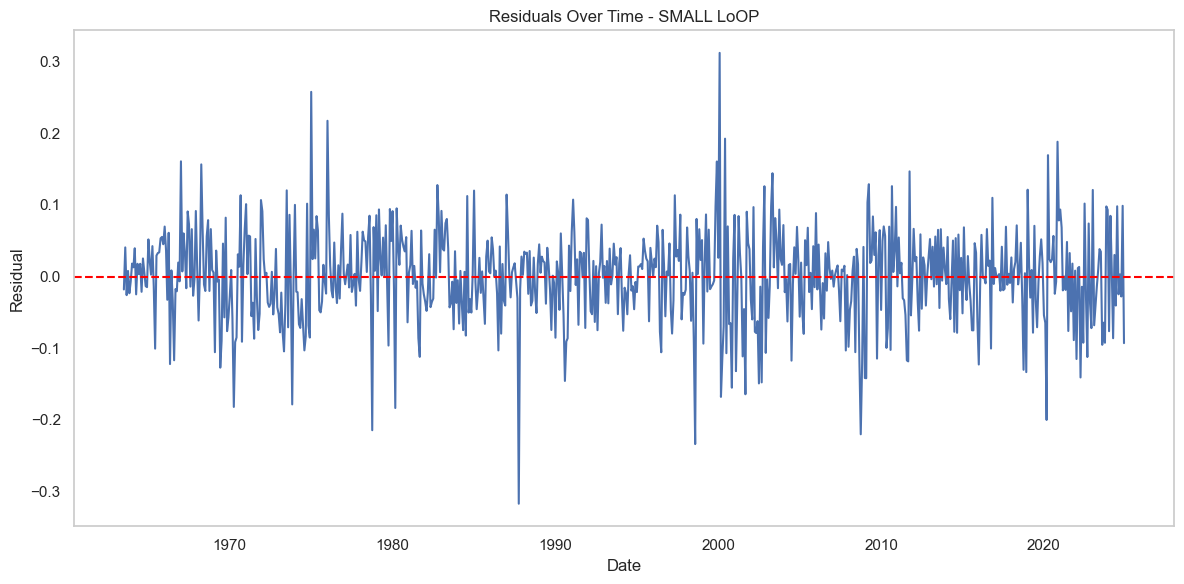

In [138]:
plt.figure(figsize=(12,6))
plt.plot(df.index, results.resid)
plt.title(f'Residuals Over Time - SMALL LoOP')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.grid()
plt.show()

In [139]:
# List of portfolios to apply ARMA(1,0,2) and find the best AIC model for each
portfolio_columns = ['ME1 OP2', 'SMALL HiOP', 'BIG LoOP', 'ME2 OP2', 'BIG HiOP']

# Apply the ARMA(1, 0, 2) model to each portfolio and print the model summary
for column in portfolio_columns:
    portfolio_data = df[column]
    
    # Initialize variables to track the best model for each portfolio
    best_aic = float('inf')  # Set initial AIC to infinity
    best_bic = float('inf')  # Set initial BIC to infinity
    best_order = None
    best_model = None

    # Try different combinations of p and q from 0 to 5 for ARMA(p, q)
    for p in range(6):
        for q in range(6):
            try:
                # Fit ARMA(p, q) model
                model = ARIMA(portfolio_data, order=(p, 0, q))  # ARMA model (p, 0, q)
                results = model.fit()
                
                # Update the best model based on AIC
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_bic = results.bic
                    best_order = (p, q)
                    best_model = results
                    residuals = results.resid

            except Exception as e:
                print(f"Error for {column} with ARMA({p},{q}): {str(e)}\n")
    
    # Print the best p and q values and the model summary
    print(f"Best ARMA({best_order[0]}, {best_order[1]}) for {column}:")
    print(best_model.summary())
    print("\n" + "-"*80 + "\n")


Best ARMA(0, 1) for ME1 OP2:
                               SARIMAX Results                                
Dep. Variable:                ME1 OP2   No. Observations:                  738
Model:                 ARIMA(0, 0, 1)   Log Likelihood                1112.391
Date:                Sun, 11 May 2025   AIC                          -2218.781
Time:                        01:00:25   BIC                          -2204.970
Sample:                    07-01-1963   HQIC                         -2213.455
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0122      0.002      5.214      0.000       0.008       0.017
ma.L1          0.1064      0.034      3.095      0.002       0.039       0.174
sigma2         0.0029  

c:\Users\denni\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\denni\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\denni\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\denni\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\denni\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information 

Best ARMA(1, 2) for SMALL LoOP:
                               SARIMAX Results                                
Dep. Variable:             SMALL LoOP   No. Observations:                  738
Model:                 ARIMA(1, 0, 2)   Log Likelihood                 969.107
Date:                Sun, 11 May 2025   AIC                          -1928.213
Time:                        21:09:18   BIC                          -1905.194
Sample:                    07-01-1963   HQIC                         -1919.337
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0095      0.001     10.036      0.000       0.008       0.011
ar.L1          0.9592      0.020     47.489      0.000       0.920       0.999
ma.L1         -0.841

c:\Users\denni\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\denni\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\denni\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\denni\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\denni\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information 

Best ARMA(0, 1) for ME1 OP2:
                               SARIMAX Results                                
Dep. Variable:                ME1 OP2   No. Observations:                  738
Model:                 ARIMA(0, 0, 1)   Log Likelihood                1112.391
Date:                Sun, 11 May 2025   AIC                          -2218.781
Time:                        21:09:48   BIC                          -2204.970
Sample:                    07-01-1963   HQIC                         -2213.455
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0122      0.002      5.214      0.000       0.008       0.017
ma.L1          0.1064      0.034      3.095      0.002       0.039       0.174
sigma2         0.0029  

c:\Users\denni\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\denni\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\denni\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\denni\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\denni\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information 

Best ARMA(1, 2) for SMALL HiOP:
                               SARIMAX Results                                
Dep. Variable:             SMALL HiOP   No. Observations:                  738
Model:                 ARIMA(1, 0, 2)   Log Likelihood                1019.917
Date:                Sun, 11 May 2025   AIC                          -2029.834
Time:                        21:10:20   BIC                          -2006.814
Sample:                    07-01-1963   HQIC                         -2020.957
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0130      0.001     10.665      0.000       0.011       0.015
ar.L1          0.9654      0.022     44.231      0.000       0.923       1.008
ma.L1         -0.851

c:\Users\denni\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\denni\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\denni\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\denni\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\denni\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information 

Best ARMA(2, 2) for BIG LoOP:
                               SARIMAX Results                                
Dep. Variable:               BIG LoOP   No. Observations:                  738
Model:                 ARIMA(2, 0, 2)   Log Likelihood                1147.606
Date:                Sun, 11 May 2025   AIC                          -2283.212
Time:                        21:10:50   BIC                          -2255.588
Sample:                    07-01-1963   HQIC                         -2272.560
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0079      0.002      4.152      0.000       0.004       0.012
ar.L1      -5.903e-05      0.140     -0.000      1.000      -0.275       0.275
ar.L2          0.9381 

c:\Users\denni\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\denni\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\denni\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\denni\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\denni\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information 

KeyboardInterrupt: 

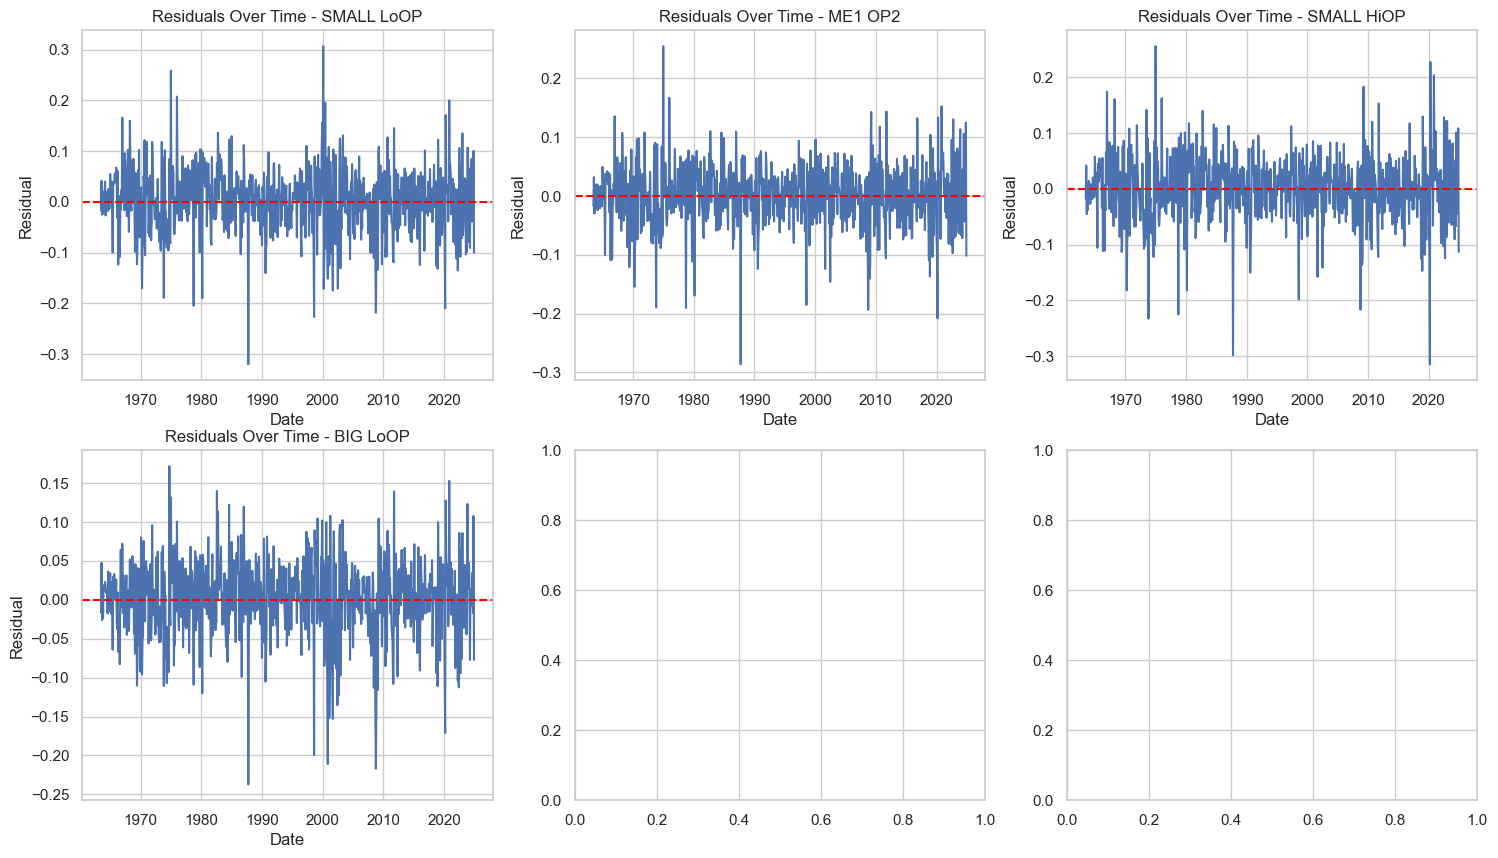

In [11]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# List of portfolios to apply ARMA(1,0,2) and find the best AIC model for each
portfolio_columns = ['SMALL LoOP', 'ME1 OP2', 'SMALL HiOP', 'BIG LoOP', 'ME2 OP2', 'BIG HiOP']

# Initialize figure for plotting residuals
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Apply the ARMA(1, 0, 2) model to each portfolio and print the model summary
for i, column in enumerate(portfolio_columns):
    portfolio_data = df[column]
    
    # Initialize variables to track the best model for each portfolio
    best_aic = float('inf')  # Set initial AIC to infinity
    best_bic = float('inf')  # Set initial BIC to infinity
    best_order = None
    best_model = None

    # Try different combinations of p and q from 0 to 5 for ARMA(p, q)
    for p in range(6):
        for q in range(6):
            try:
                # Fit ARMA(p, q) model
                model = ARIMA(portfolio_data, order=(p, 0, q))  # ARMA model (p, 0, q)
                results = model.fit()
                
                # Update the best model based on AIC
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_bic = results.bic
                    best_order = (p, q)
                    best_model = results
                    residuals = results.resid

            except Exception as e:
                print(f"Error for {column} with ARMA({p},{q}): {str(e)}\n")
    
    # Print the best p and q values and the model summary
    print(f"Best ARMA({best_order[0]}, {best_order[1]}) for {column}:")
    print(best_model.summary())
    print("\n" + "-"*80 + "\n")

    # Plot residuals over time for each portfolio
    ax = axes[i // 3, i % 3]  # Determine the position in the grid (2x3)
    ax.plot(df.index, residuals)
    ax.set_title(f'Residuals Over Time - {column}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Residual')
    ax.axhline(0, color='red', linestyle='--')
    ax.grid(True)

# Adjust layout for better visibility
plt.tight_layout()
plt.show()


Model Performance:
Portfolio       Model           Log-Likelihood  AIC             BIC            
---------------------------------------------------------------------------
SMALL LoOP      GARCH           -2420.22        4848.44         4866.86        
SMALL LoOP      GJR-GARCH       -2418.48        4846.95         4869.97        
SMALL LoOP      EGARCH          -2418.89        4845.78         4864.20        
---------------------------------------------------------------------------


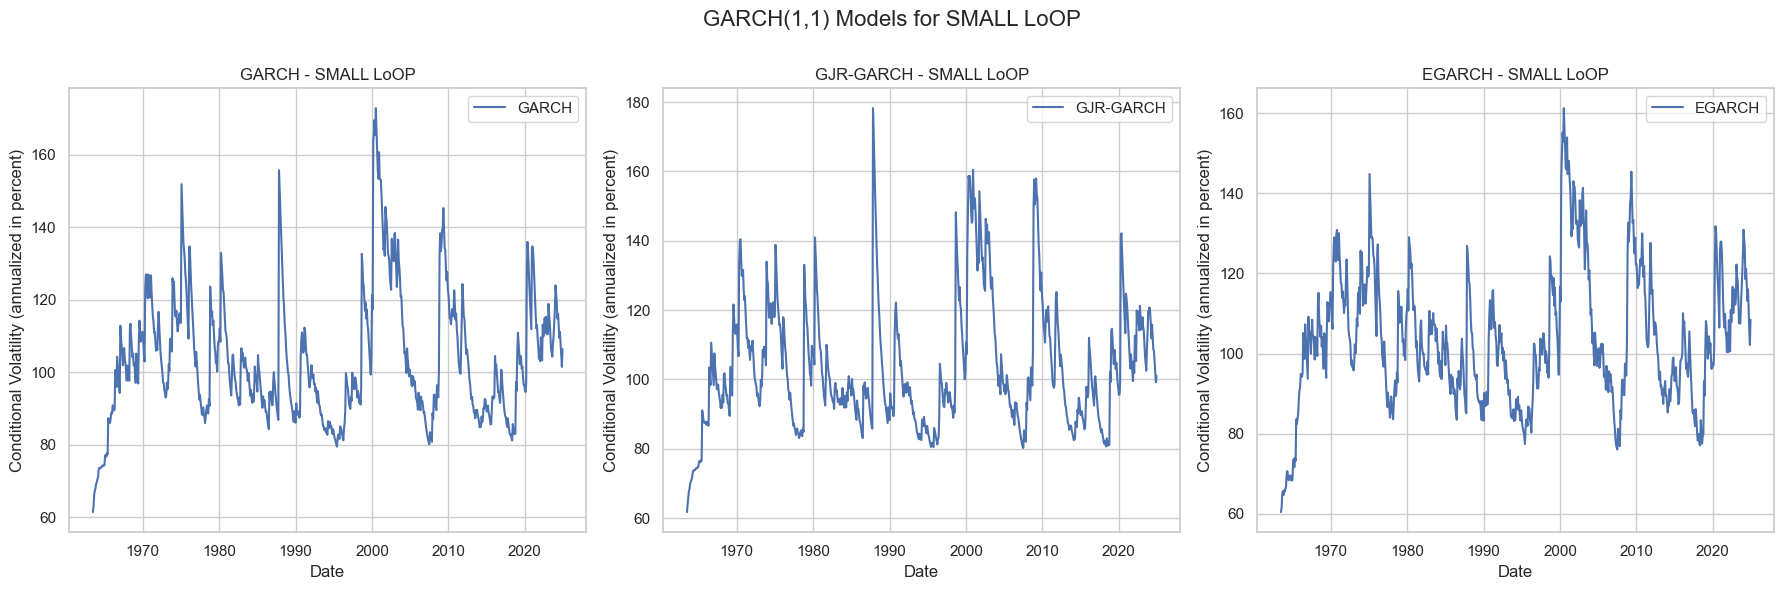

ME1 OP2         GARCH           -2275.54        4559.08         4577.50        
ME1 OP2         GJR-GARCH       -2262.29        4534.59         4557.61        
ME1 OP2         EGARCH          -2269.78        4547.57         4565.98        
---------------------------------------------------------------------------


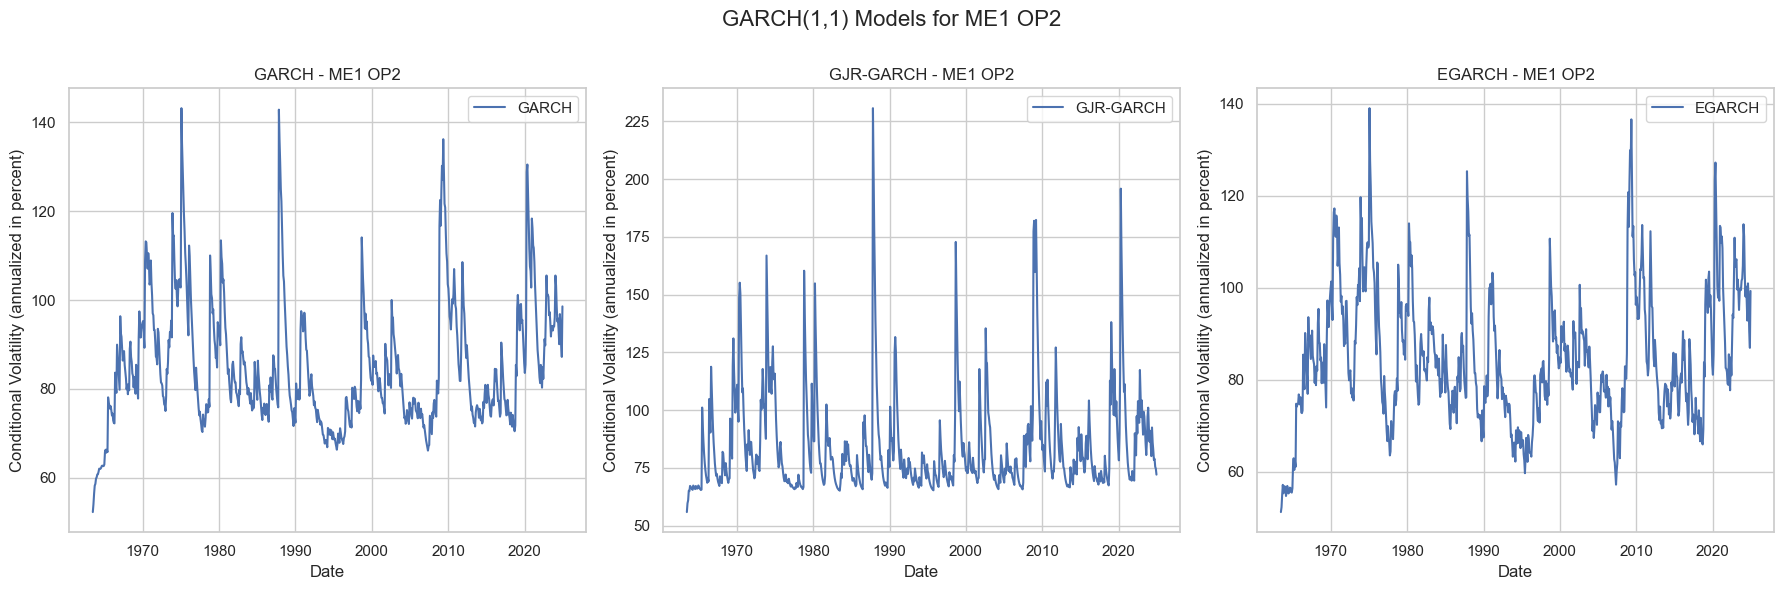

SMALL HiOP      GARCH           -2362.66        4733.33         4751.74        
SMALL HiOP      GJR-GARCH       -2348.07        4706.14         4729.16        
SMALL HiOP      EGARCH          -2357.03        4722.07         4740.48        
---------------------------------------------------------------------------


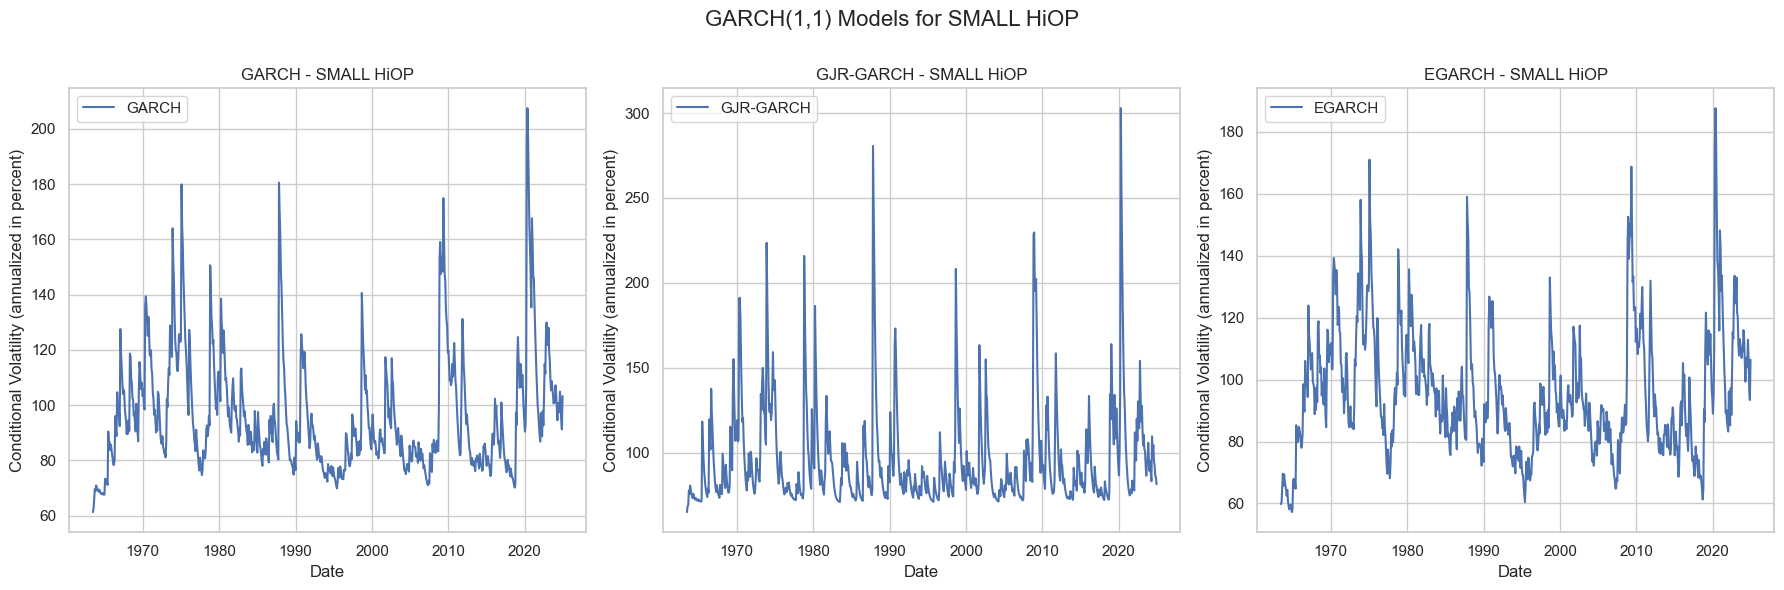

BIG LoOP        GARCH           -2211.33        4430.66         4449.07        
BIG LoOP        GJR-GARCH       -2201.65        4413.30         4436.32        
BIG LoOP        EGARCH          -2210.20        4428.41         4446.82        
---------------------------------------------------------------------------


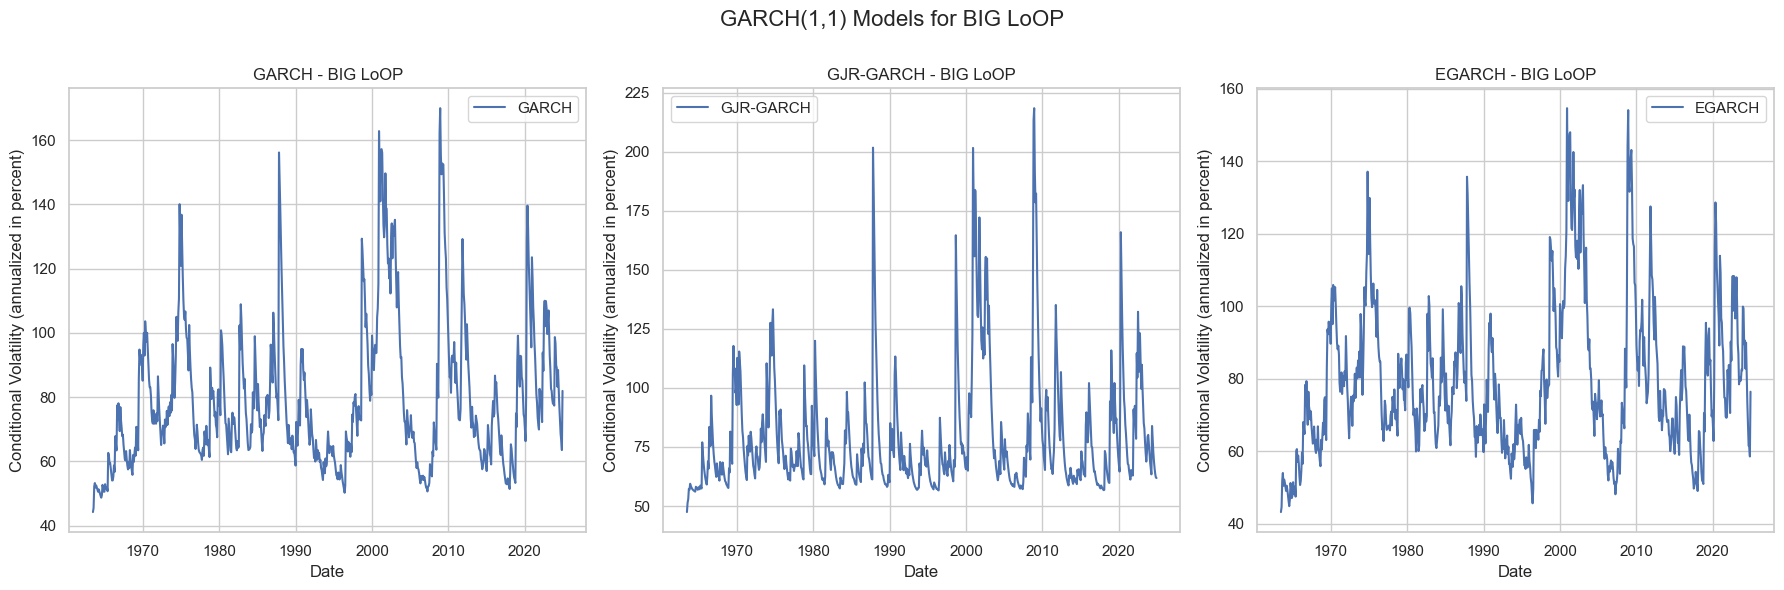

ME2 OP2         GARCH           -2092.65        4193.30         4211.72        
ME2 OP2         GJR-GARCH       -2083.93        4177.86         4200.88        
ME2 OP2         EGARCH          -2088.01        4184.01         4202.43        
---------------------------------------------------------------------------


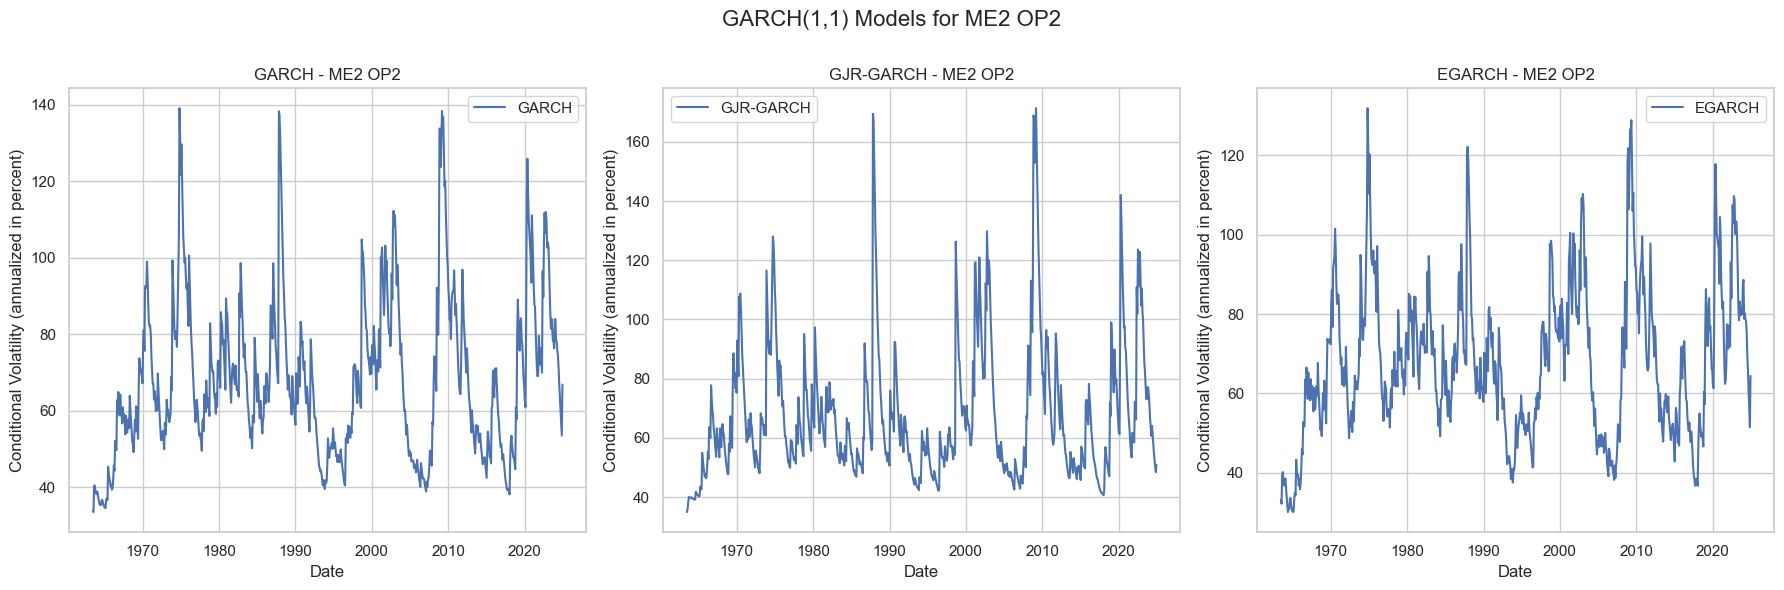

BIG HiOP        GARCH           -2111.32        4230.64         4249.06        
BIG HiOP        GJR-GARCH       -2106.33        4222.66         4245.68        
BIG HiOP        EGARCH          -2109.08        4226.17         4244.58        
---------------------------------------------------------------------------


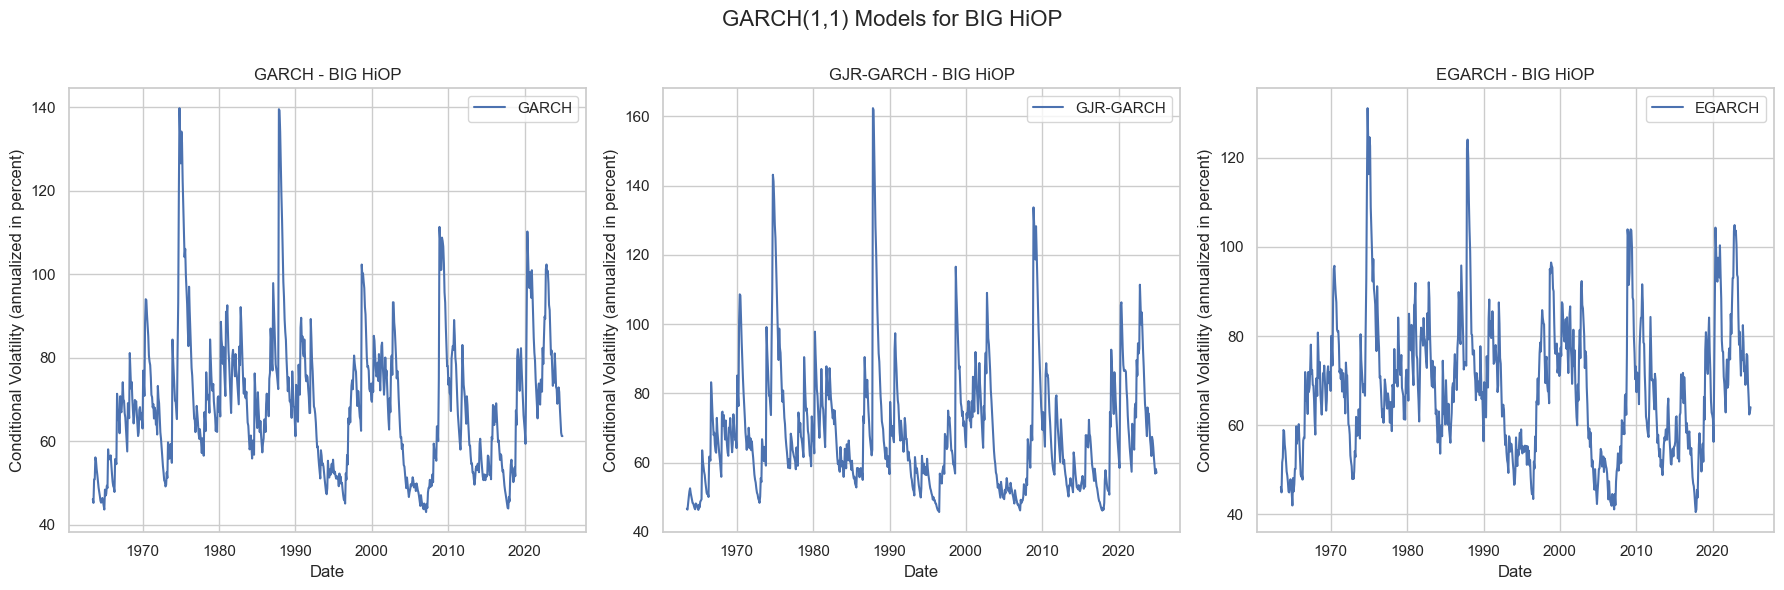

In [ ]:
from arch import arch_model
import matplotlib.pyplot as plt
import numpy as np

portfolio_columns = ['SMALL LoOP', 'ME1 OP2', 'SMALL HiOP', 'BIG LoOP', 'ME2 OP2', 'BIG HiOP']

# Print the model performance header
print(f"Model Performance:")
print("="*75)
print(f"{'Portfolio':<15} {'Model':<15} {'Log-Likelihood':<15} {'AIC':<15} {'BIC':<15}")
print("-"*75)

# Loop through each portfolio
for portfolio in portfolio_columns:
    returns = df[portfolio].dropna()
    scale_factor = 100  # Scaling factor for annualization

    # Initialize dictionary to store results for GARCH models
    results = {}

    # Fit GARCH(1,1) model
    model_garch = arch_model(returns * scale_factor, vol='GARCH', mean='AR', lags=0, p=1, q=1)
    results['GARCH'] = model_garch.fit(disp='off')

    # Fit GJR-GARCH(1,1) model
    model_gjr = arch_model(returns * scale_factor, vol='GARCH', mean='AR', lags=0, p=1, o=1, q=1)
    results['GJR-GARCH'] = model_gjr.fit(disp='off')

    # Fit EGARCH(1,1) model
    model_egarch = arch_model(returns * scale_factor, vol='EGARCH', mean='AR', lags=0, p=1, q=1)
    results['EGARCH'] = model_egarch.fit(disp='off')

    # Print model performance metrics for each portfolio
    for name, result in results.items():
        print(f"{portfolio:<15} {name:<15} {result.loglikelihood:<15.2f} {result.aic:<15.2f} {result.bic:<15.2f}")

    print("-"*75)

    # Plot returns and conditional volatilities for GARCH models (1 row, 3 columns)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'GARCH(1,1) Models for {portfolio}', fontsize=16)

    # Plot for each GARCH model in the same row
    for ax, (name, result) in zip(axes, results.items()):
        ax.plot(result.conditional_volatility / scale_factor * np.sqrt(252) * 100, label=name)
        ax.set_title(f'{name} - {portfolio}')
        ax.set_xlabel('Date')
        ax.set_ylabel('Conditional Volatility (annualized in percent)')
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)  # Adjust title placement
    plt.show()


# Statistical Arbitrage Trading Strategies

### Joint Multivariate Time Series Modelling

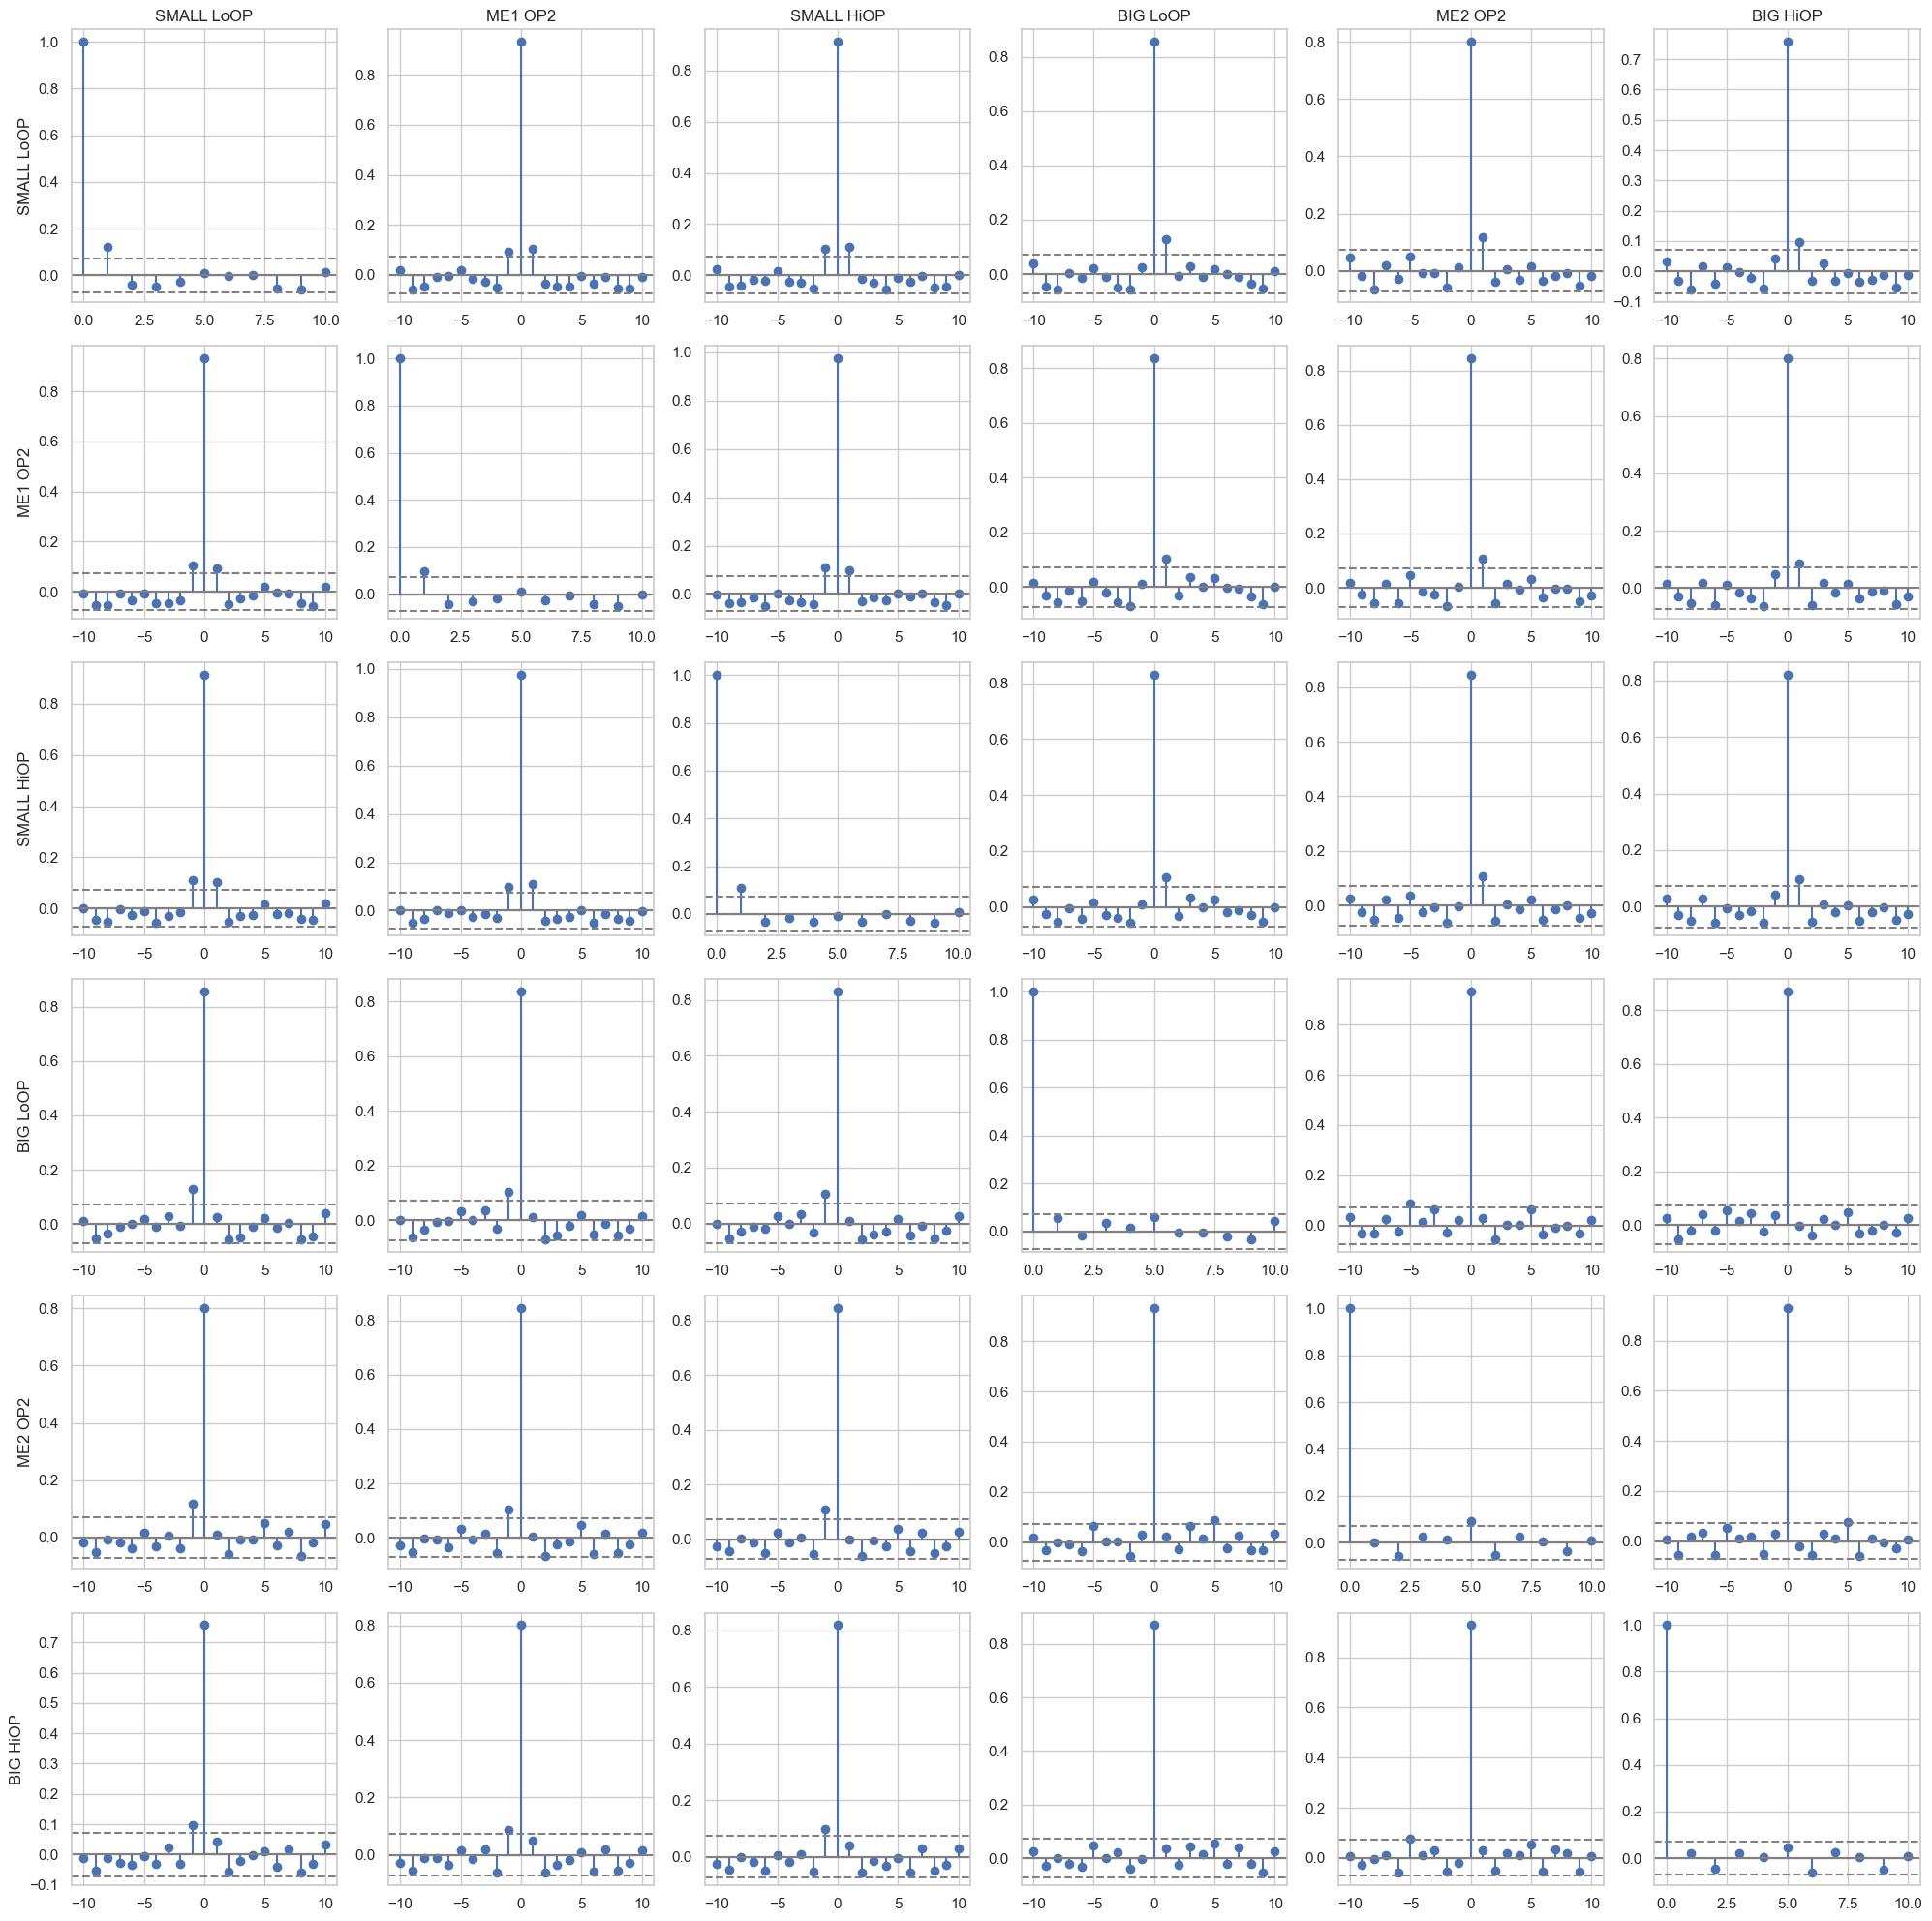

In [ ]:
# Calculate ACF matrices
lags = 10
returns = np.column_stack([df[col] for col in df])
n = returns.shape[1]

# Function to calculate cross-correlation
def ccf(x, y, lag_max):
    result = []
    for lag in range(-lag_max, lag_max+1):
        if lag < 0:
            # For negative lag k, take elements from index |k| to end
            slice1 = y[-lag:]  # e.g. if lag=-2, takes y[2:], skipping first 2 elements
            slice2 = x[:lag]  # e.g. if lag=-2, takes x[:-2], skipping last 2 elements
        elif lag == 0:
            slice1 = x
            slice2 = y
        else:
            slice1 = y[:-lag]
            slice2 = x[lag:]
        result.append(np.corrcoef(slice1, slice2)[0,1])
    return result

# Create figure with 3x3 subplots
fig, axes = plt.subplots(6, 6, figsize=(20, 20))

titles = [col for col in df]

for i in range(n):
    for j in range(n):
        if i == j:
            # Plot ACF on diagonal
            acf_values = acf(returns[:,i], nlags=lags)
            axes[i,j].stem(range(lags+1), acf_values)
        else:
            # Plot CCF off diagonal
            ccf_values = ccf(returns[:,i], returns[:,j], lags)
            axes[i,j].stem(range(-lags, lags+1), ccf_values)
            
        # Add confidence bands
        axes[i,j].axhline(y=0, linestyle='-', color='gray')
        axes[i,j].axhline(y=1.96/np.sqrt(len(returns)), linestyle='--', color='gray')
        axes[i,j].axhline(y=-1.96/np.sqrt(len(returns)), linestyle='--', color='gray')
        
        # Add titles
        if i == 0:
            axes[i,j].set_title(f'{titles[j]}')
        if j == 0:
            axes[i,j].set_ylabel(f'{titles[i]}')

plt.tight_layout()
plt.show()


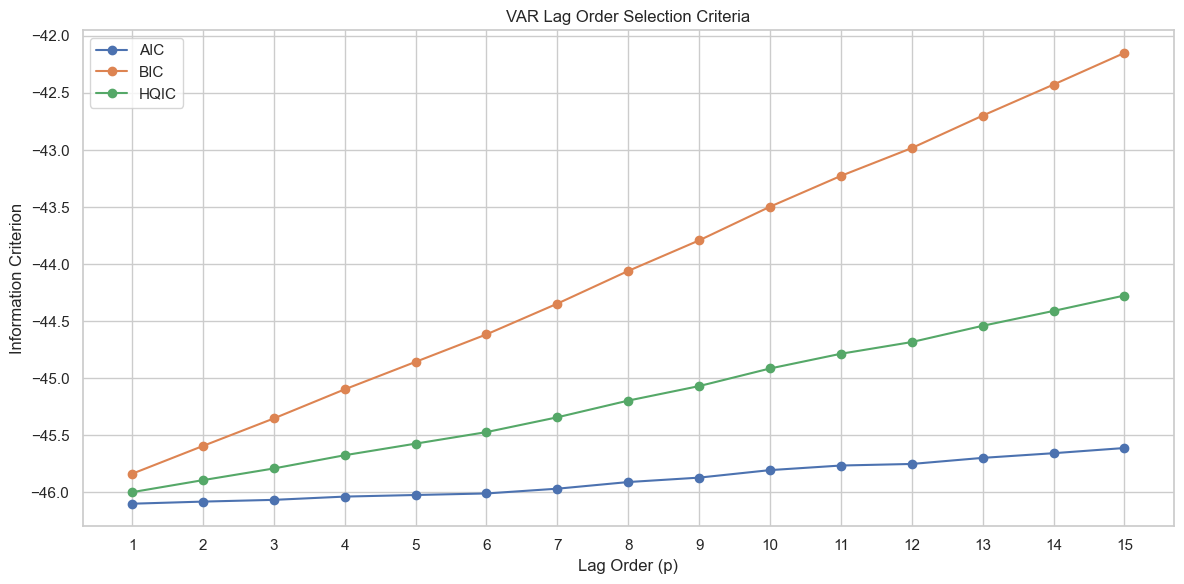

,AIC,BIC,HQIC
Selected Lag,1,1,1


In [23]:
from statsmodels.tsa.api import VAR

# Fit VAR models for lag orders 1 to 15 and collect information criteria
lag_criteria = {'AIC': [], 'BIC': [], 'HQIC': []}
lags = list(range(1, 16))

for p in lags:
    var_model = VAR(df)
    var_res = var_model.fit(p)
    lag_criteria['AIC'].append(var_res.aic)
    lag_criteria['BIC'].append(var_res.bic)
    lag_criteria['HQIC'].append(var_res.hqic)

# Plot AIC, BIC, HQIC for different lag orders
plt.figure(figsize=(12, 6))
plt.plot(lags, lag_criteria['AIC'], marker='o', label='AIC')
plt.plot(lags, lag_criteria['BIC'], marker='o', label='BIC')
plt.plot(lags, lag_criteria['HQIC'], marker='o', label='HQIC')
plt.title('VAR Lag Order Selection Criteria')
plt.xlabel('Lag Order (p)')
plt.ylabel('Information Criterion')
plt.xticks(lags)
plt.legend()
plt.tight_layout()
plt.show()

# Identify selected lag order for each criterion
selected_lags = {
    'AIC': lags[int(pd.Series(lag_criteria['AIC']).idxmin())],
    'BIC': lags[int(pd.Series(lag_criteria['BIC']).idxmin())],
    'HQIC': lags[int(pd.Series(lag_criteria['HQIC']).idxmin())]
}

# Display the selected lag orders
import pandas as _pd
_pd.DataFrame(selected_lags, index=['Selected Lag'])

### Granger Causality Test

In [24]:
model = VAR(df)
final_model = model.fit(1)

# Perform Granger causality tests between all pairs of squared returns
print("\nGranger Causality Tests:")

pairs = [(i, j, portfolio_columns[i], portfolio_columns[j]) for i, j in combinations(range(len(portfolio_columns)), 2)]

print(pairs)
# Test pairwise causality
for target, source, target_name, source_name in pairs:
    print(f"\nTesting causality from {source_name} to {target_name}:")
    print(final_model.test_causality(target, [source]).summary())

# Test joint causality
for i, name in enumerate(['SMALL LoOP', 'ME1 OP2', 'SMALL HiOP','BIG LoOP','ME2 OP2','BIG HiOP']):
    others = [j for j in range(6) if j != i]
    print(f"\nTesting joint causality on {name}:")
    print(final_model.test_causality(i, others).summary())


Granger Causality Tests:
[(0, 1, 'SMALL LoOP', 'ME1 OP2'), (0, 2, 'SMALL LoOP', 'SMALL HiOP'), (0, 3, 'SMALL LoOP', 'BIG LoOP'), (0, 4, 'SMALL LoOP', 'ME2 OP2'), (0, 5, 'SMALL LoOP', 'BIG HiOP'), (1, 2, 'ME1 OP2', 'SMALL HiOP'), (1, 3, 'ME1 OP2', 'BIG LoOP'), (1, 4, 'ME1 OP2', 'ME2 OP2'), (1, 5, 'ME1 OP2', 'BIG HiOP'), (2, 3, 'SMALL HiOP', 'BIG LoOP'), (2, 4, 'SMALL HiOP', 'ME2 OP2'), (2, 5, 'SMALL HiOP', 'BIG HiOP'), (3, 4, 'BIG LoOP', 'ME2 OP2'), (3, 5, 'BIG LoOP', 'BIG HiOP'), (4, 5, 'ME2 OP2', 'BIG HiOP')]

Testing causality from ME1 OP2 to SMALL LoOP:
Granger causality F-test. H_0: ME1 OP2 does not Granger-cause SMALL LoOP. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
         1.519          3.844   0.218 (1, 4380)
-----------------------------------------------

Testing causality from SMALL HiOP to SMALL LoOP:
Granger causality F-test. H_0: SMALL HiOP does not Granger-caus

### Engle - Granger Cointegration Test

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

# List to store results
cointegration_results = []

# Perform Engle-Granger test for each portfolio pair
for i, j, portfolio1, portfolio2 in pairs:
    # Extract the price series for each portfolio
    series1 = price_df[portfolio1]
    series2 = price_df[portfolio2]

    # Estimate hedge ratio using OLS regression
    ols_model = sm.OLS(series1, sm.add_constant(series2))
    ols_results = ols_model.fit()
    hedge_ratio = ols_results.params[1]

    # Calculate the spread between the portfolios
    spread = series1 - hedge_ratio * series2

    # Run Engle-Granger cointegration test
    test_stat, p_value, critical_values = coint(series1, series2)

    # Append results to the list
    cointegration_results.append({
        'Pair': f"{portfolio1} vs {portfolio2}",
        'Test Statistic': round(test_stat, 4),
        'p-value': round(p_value, 4),
        '1% CV': round(critical_values[0], 4),
        '5% CV': round(critical_values[1], 4),
        'Cointegrated (5%)': 'Yes' if p_value < 0.05 else 'No',
        'Cointegrated (10%)': '            Yes' if p_value < 0.1 else '            No'
    })

# Convert results list to DataFrame
cointegration_df = pd.DataFrame(cointegration_results)

# Sort the results by p-value and reset index
cointegration_df = cointegration_df.sort_values(by='p-value').reset_index(drop=True)

# Print formatted results
print("Engle-Granger Cointegration Test Results")
print("=" * 130)
header = f"{'Pair':^30} {'Test Statistic':^15} {'p-value':^15} {'1% CV':^15} {'5% CV':^15} {'Cointegrated (5%)':^15} {'   Cointegrated (10%)':^15}"
print(header)
print("-" * len(header))

# Display each row in the sorted DataFrame
for _, row in cointegration_df.iterrows():
    print(f"{row['Pair']:^30} {row['Test Statistic']:^15} {row['p-value']:^15.4f} {row['1% CV']:^15.4f} {row['5% CV']:^15.4f} {row['Cointegrated (5%)']:^15} {row['Cointegrated (10%)']:^15}")

print("=" * 130)


Engle-Granger Cointegration Test Results
             Pair              Test Statistic      p-value          1% CV           5% CV      Cointegrated (5%)    Cointegrated (10%)
--------------------------------------------------------------------------------------------------------------------------------------
    ME1 OP2 vs SMALL HiOP          -3.1848         0.0725          -3.9114         -3.3444           No                    Yes
    SMALL LoOP vs ME1 OP2          -3.1324         0.0820          -3.9114         -3.3444           No                    Yes
     ME1 OP2 vs BIG LoOP           -2.9255         0.1290          -3.9114         -3.3444           No                    No 
      ME1 OP2 vs ME2 OP2           -2.7283         0.1896          -3.9114         -3.3444           No                    No 
    SMALL HiOP vs BIG LoOP         -2.7242         0.1910          -3.9114         -3.3444           No                    No 
   SMALL LoOP vs SMALL HiOP        -2.7129         0.1

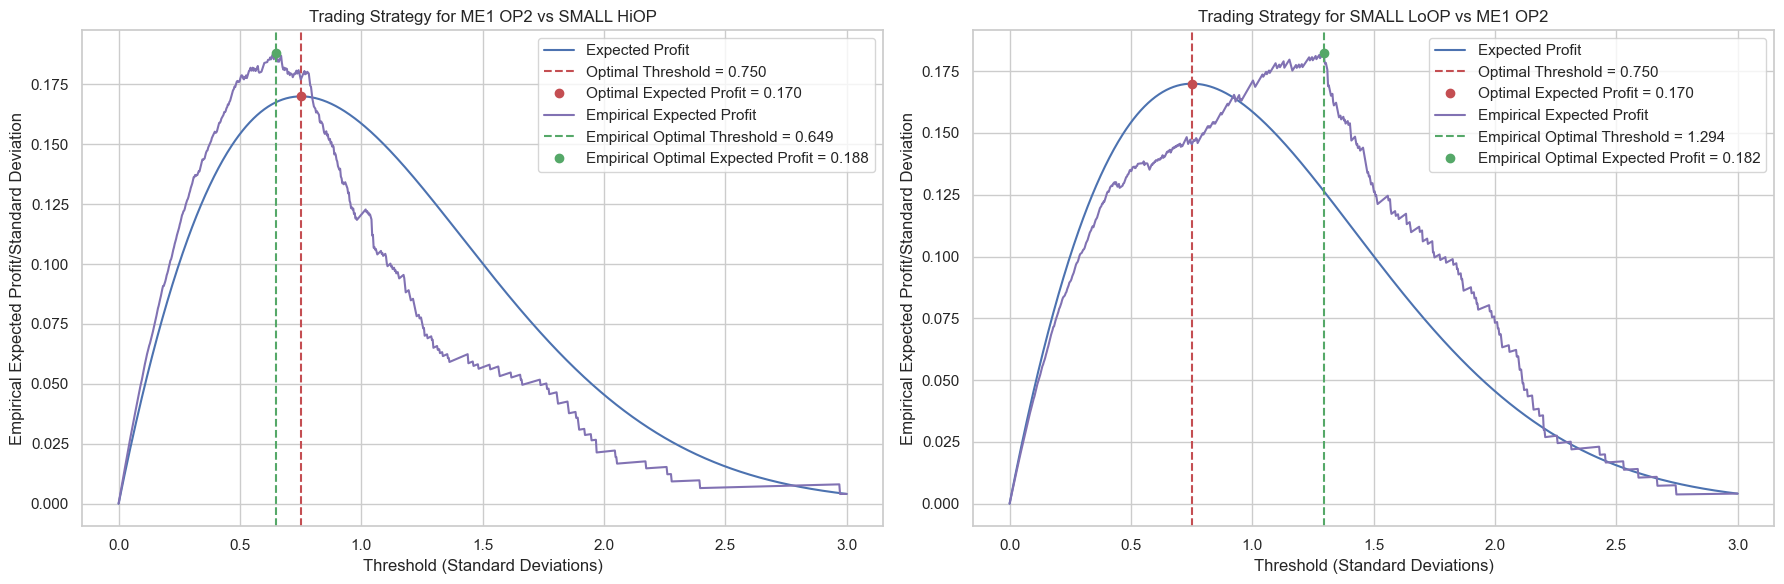

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import statsmodels.api as sm

# Bisection search to find the optimal threshold
def bisection_search(f, a, b, tol=1e-6, max_iter=100):
    for _ in range(max_iter):
        # Find midpoints
        c = (a + b) / 2 - tol / 2
        d = (a + b) / 2 + tol / 2
        
        # Evaluate function at midpoints
        fc, fd = f(c), f(d)
        
        # Narrow the interval based on the function values
        if fc > f(b):
            b = c
        else:
            a = d
        
        # Check if tolerance level is met
        if abs(b - a) < tol:
            break
            
    return (a + b) / 2

# Function to calculate expected profit assuming standard normal distribution
def expected_profit(threshold):
    return (1 - norm.cdf(threshold)) * threshold

# Function to calculate empirical profit based on trading frequency
def empirical_profit(threshold):
    return threshold * np.mean(z_scores > threshold)

# Define the pairs of portfolios
pairs = [
    ('ME1 OP2', 'SMALL HiOP'),
    ('SMALL LoOP', 'ME1 OP2')
]

# Create a 1-row, 2-column subplot for the two pairs
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Loop through each pair of cointegrated portfolios
for idx, (portfolio1, portfolio2) in enumerate(pairs):
    # Extract price data for the portfolios
    series1 = price_df[portfolio1]
    series2 = price_df[portfolio2]

    # Fit linear model to estimate hedge ratio (gamma)
    model = sm.OLS(series1, sm.add_constant(series2))
    results = model.fit()
    gamma = results.params[1]

    # Calculate the spread between the two portfolios
    spread = series1 - gamma * series2

    # Search for optimal threshold using bisection search between 0 and 3 standard deviations
    optimal_threshold = bisection_search(expected_profit, 0, 3)

    # Plot the expected profit function
    thresholds = np.linspace(0, 3, 1000)
    profits = [expected_profit(threshold) for threshold in thresholds]

    # Plot expected profit in the current subplot
    ax = axes[idx]
    ax.plot(thresholds, profits, 'b-', label='Expected Profit')
    ax.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Optimal Threshold = {optimal_threshold:.3f}')
    ax.plot(optimal_threshold, expected_profit(optimal_threshold), 'ro', label=f'Optimal Expected Profit = {expected_profit(optimal_threshold):.3f}')
    
    # Standardize the spread for Z-scores
    spread_mean, spread_std = np.mean(spread), np.std(spread)
    z_scores = (spread - spread_mean) / spread_std

    # Calculate and plot empirical expected profits for different thresholds
    empirical_expected_profits = [empirical_profit(threshold) for threshold in thresholds]
    optimal_threshold_empirical = thresholds[np.argmax(empirical_expected_profits)]

    # Plot empirical expected profit in the current subplot
    ax.plot(thresholds, empirical_expected_profits, 'm-', label='Empirical Expected Profit')
    ax.axvline(x=optimal_threshold_empirical, color='g', linestyle='--', label=f'Empirical Optimal Threshold = {optimal_threshold_empirical:.3f}')
    ax.plot(optimal_threshold_empirical, empirical_profit(optimal_threshold_empirical), 'go', label=f'Empirical Optimal Expected Profit = {empirical_profit(optimal_threshold_empirical):.3f}')
    
    ax.set_xlabel('Threshold (Standard Deviations)')
    ax.set_ylabel('Empirical Expected Profit/Standard Deviation')
    ax.grid(True)
    ax.legend()
    ax.set_title(f'Trading Strategy for {portfolio1} vs {portfolio2}')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


### Rolling Window Approach

In [202]:
price_df

,SMALL LoOP,ME1 OP2,SMALL HiOP,BIG LoOP,ME2 OP2,BIG HiOP
Date,,,,,,
1963-07-01,0.689048,0.690838,0.691067,0.688910,0.695053,0.693695
1963-08-01,0.712915,0.711672,0.717104,0.715984,0.719690,0.722230
1963-09-01,0.707719,0.704352,0.703193,0.707156,0.715569,0.714745
1963-10-01,0.714626,0.711959,0.711323,0.711291,0.723128,0.745737
1963-11-01,0.708187,0.706340,0.699176,0.703856,0.724642,0.738613
...,...,...,...,...,...,...
2024-08-01,5.511879,7.835518,8.026655,4.754865,5.926403,6.916849
2024-09-01,5.516179,7.842315,8.043892,4.788619,5.944578,6.938920
2024-10-01,5.506903,7.833152,8.026700,4.788223,5.955511,6.918497


In [25]:
import pandas as pd
import statsmodels.api as sm

warnings.filterwarnings('ignore')

# price_df = price_df[price_df.index.year >= 1990]

pairs = [('ME1 OP2', 'SMALL HiOP')]
# Assuming df_price contains your price data
# Example pair, replace with your list of pairs
window_size = 72  # Rolling window size

df_rolling = pd.DataFrame()
returns = np.zeros(len(price_df))  # Set the length equal to the df_rolling length

# Loop through each pair of stocks
for pair in pairs:
    y = price_df[pair[0]]  # Stock y
    x = price_df[pair[1]]  # Stock x
    
    spread_rolling_mean = []  # List to store rolling mean of spread
    spread_rolling_std = []  # List to store rolling std of spread
    signal = []  # List to store buy/short signals
    position = []  # List to store positions (1 for buy, -1 for short, 0 for unwind)
    current_position = 0
    spread_df = []

    # Rolling window loop
    for start in range(len(y) - window_size):
        end = start + window_size
        y_window = y[start:end]
        x_window = x[start:end]
        
        # Fit OLS model for current window
        model = sm.OLS(y_window, sm.add_constant(x_window))  # Add constant for the intercept
        results = model.fit()
        
        # Extract gamma and mu from the OLS results
        gamma = results.params[1]
        mu = results.params[0]
        
        # Calculate spread for current window
        spread = y_window - gamma * x_window - mu
        
        # Calculate rolling mean and standard deviation of spread
        spread_mean = spread.mean()
        spread_std = spread.std()
    
        z_score = (spread.iloc[-1]-spread_mean)/spread_std
        spread_df.append(z_score)
        # Threshold s0 is one standard deviation of the spread
        s0 = 1.5
        se = 0.01
        
        if z_score <= -s0:  #and current_position != 1# Buy signal (no current long position) (long y short x)
            signal.append('buy')
            position.append(1)
            current_position = 1  # Now in a long position
        elif z_score >= s0:  #and current_position != -1 Short-sell signal (no current short position)
            signal.append('sell')
            position.append(-1)
            current_position = -1  # Now in a short position
        elif abs(z_score) <= se:
            signal.append('exit')
            position.append(0)
            current_position = 0  # No position
        else:  # No action if no trade condition is met
            signal.append('hold')
            # position.append(current_position)
            if not position:
                position.append(0)
            else:
                if position[-1] == 0:
                    position.append(0)
                else:
                    position.append(position[-1])

        returns[start + window_size] = position[-1] * (spread.iloc[-1] - spread.iloc[-2]) * -1  # Compare the spread

        spread_rolling_mean.append(spread_mean)
        spread_rolling_std.append(spread_std)
    
    # Store the results as new columns in the DataFrame
    df_rolling['spread_rolling_mean'] = pd.Series(spread_rolling_mean, index=price_df.index[window_size:])
    df_rolling['spread_rolling_std'] = pd.Series(spread_rolling_std, index=price_df.index[window_size:])
    df_rolling['z_scores'] = pd.Series(spread_df, index=price_df.index[window_size:])
    df_rolling['signal'] = pd.Series(signal, index=price_df.index[window_size:])
    df_rolling['position'] = pd.Series(position, index=price_df.index[window_size:])
    df_rolling = df_rolling.dropna()
    
    df_rolling['strategy_returns'] = returns[window_size:]  # Set strategy returns for the pair
    df_rolling['cumret'] = np.cumsum(df_rolling['strategy_returns'])  # Calculate cumulative returns

df_rolling[['spread_rolling_mean', 'spread_rolling_std','z_scores', 'signal', 'position', 'cumret']].head(20)
df_rolling

,spread_rolling_mean,spread_rolling_std,z_scores,signal,position,strategy_returns,cumret
Date,,,,,,,
1969-07-01,-3.176471e-16,0.013682,-0.275408,hold,0,0.000000,0.000000
1969-08-01,2.528841e-16,0.013381,-0.143627,hold,0,-0.000000,0.000000
1969-09-01,3.207311e-16,0.013123,-1.043069,hold,0,0.000000,0.000000
1969-10-01,1.541976e-16,0.013180,-1.867020,buy,1,0.011859,0.011859
1969-11-01,1.372359e-16,0.013105,-1.477154,hold,1,-0.004433,0.007426
...,...,...,...,...,...,...,...
2024-08-01,4.909653e-15,0.035575,2.442112,sell,-1,0.018613,0.252924
2024-09-01,-1.656699e-14,0.036721,2.131503,sell,-1,-0.005353,0.247571
2024-10-01,2.343804e-15,0.037342,1.795124,sell,-1,-0.008506,0.239064


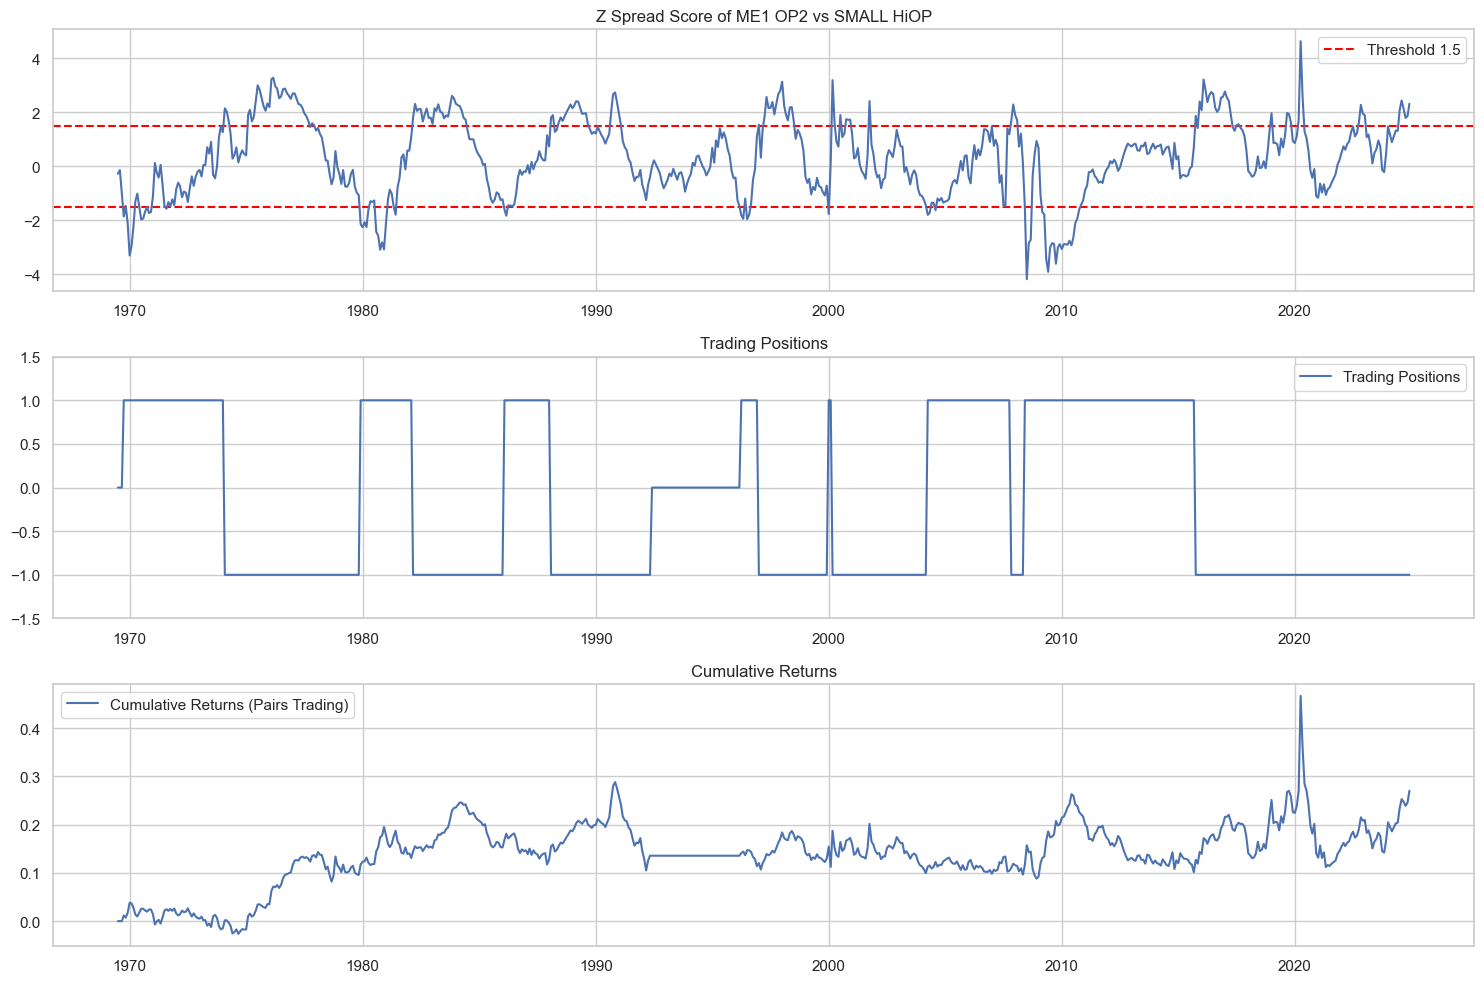

In [26]:
spread_plot = pd.DataFrame({'z_score': spread_df}, index=price_df.index[window_size:])


plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.axhline(y=1.5, color='red', linestyle='--', linewidth=1.5, label='Threshold 1.5')
plt.axhline(y=-1.5, color='red', linestyle='--', linewidth=1.5)
plt.plot(spread_plot.index,spread_plot['z_score'])
plt.title('Z Spread Score of ME1 OP2 vs SMALL HiOP')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(df_rolling['position'], label='Trading Positions')
plt.title('Trading Positions')
plt.ylim([-1.5, 1.5])
plt.legend()
plt.grid(True)

# 3rd subplot: Cumulative Returns
plt.subplot(3, 1, 3)
plt.plot(df_rolling['cumret'], label='Cumulative Returns (Pairs Trading)')
plt.title('Cumulative Returns')
plt.legend()
plt.grid(True)

# # Show the plots
plt.tight_layout()
plt.show()

In [27]:
import pandas as pd
import statsmodels.api as sm

warnings.filterwarnings('ignore')

# price_df = price_df[price_df.index.year >= 1990]

pairs = [('ME1 OP2', 'SMALL LoOP')]
# Assuming df_price contains your price data
# Example pair, replace with your list of pairs
window_size = 72  # Rolling window size

df_rolling = pd.DataFrame()
returns = np.zeros(len(price_df))  # Set the length equal to the df_rolling length

# Loop through each pair of stocks
for pair in pairs:
    y = price_df[pair[0]]  # Stock y
    x = price_df[pair[1]]  # Stock x
    
    spread_rolling_mean = []  # List to store rolling mean of spread
    spread_rolling_std = []  # List to store rolling std of spread
    signal = []  # List to store buy/short signals
    position = []  # List to store positions (1 for buy, -1 for short, 0 for unwind)
    current_position = 0
    spread_df = []

    # Rolling window loop
    for start in range(len(y) - window_size):
        end = start + window_size
        y_window = y[start:end]
        x_window = x[start:end]
        
        # Fit OLS model for current window
        model = sm.OLS(y_window, sm.add_constant(x_window))  # Add constant for the intercept
        results = model.fit()
        
        # Extract gamma and mu from the OLS results
        gamma = results.params[1]
        mu = results.params[0]
        
        # Calculate spread for current window
        spread = y_window - gamma * x_window - mu
        
        # Calculate rolling mean and standard deviation of spread
        spread_mean = spread.mean()
        spread_std = spread.std()
    
        z_score = (spread.iloc[-1]-spread_mean)/spread_std
        spread_df.append(z_score)
        # Threshold s0 is one standard deviation of the spread
        s0 = 1.5
        se = 0.01
        
        if z_score <= -s0:  #and current_position != 1# Buy signal (no current long position) (long y short x)
            signal.append('buy')
            position.append(1)
            current_position = 1  # Now in a long position
        elif z_score >= s0:  #and current_position != -1 Short-sell signal (no current short position)
            signal.append('sell')
            position.append(-1)
            current_position = -1  # Now in a short position
        elif abs(z_score) <= se:
            signal.append('exit')
            position.append(0)
            current_position = 0  # No position
        else:  # No action if no trade condition is met
            signal.append('hold')
            # position.append(current_position)
            if not position:
                position.append(0)
            else:
                if position[-1] == 0:
                    position.append(0)
                else:
                    position.append(position[-1])

        returns[start + window_size] = position[-1] * (spread.iloc[-1] - spread.iloc[-2]) * -1  # Compare the spread

        spread_rolling_mean.append(spread_mean)
        spread_rolling_std.append(spread_std)
    
    # Store the results as new columns in the DataFrame
    df_rolling['spread_rolling_mean'] = pd.Series(spread_rolling_mean, index=price_df.index[window_size:])
    df_rolling['spread_rolling_std'] = pd.Series(spread_rolling_std, index=price_df.index[window_size:])
    df_rolling['z_scores'] = pd.Series(spread_df, index=price_df.index[window_size:])
    df_rolling['signal'] = pd.Series(signal, index=price_df.index[window_size:])
    df_rolling['position'] = pd.Series(position, index=price_df.index[window_size:])
    df_rolling = df_rolling.dropna()
    
    df_rolling['strategy_returns'] = returns[window_size:]  # Set strategy returns for the pair
    df_rolling['cumret'] = np.cumsum(df_rolling['strategy_returns'])  # Calculate cumulative returns

df_rolling[['spread_rolling_mean', 'spread_rolling_std','z_scores', 'signal', 'position', 'cumret']].head(20)
df_rolling

,spread_rolling_mean,spread_rolling_std,z_scores,signal,position,strategy_returns,cumret
Date,,,,,,,
1969-07-01,-3.469447e-16,0.018499,-1.412803,hold,0,0.000000,0.000000
1969-08-01,5.551115e-17,0.018619,-1.348720,hold,0,0.000000,0.000000
1969-09-01,-3.238150e-17,0.018696,-1.167761,hold,0,-0.000000,0.000000
1969-10-01,7.540265e-16,0.018703,-1.134119,hold,0,0.000000,0.000000
1969-11-01,1.341519e-16,0.018659,-0.877695,hold,0,-0.000000,0.000000
...,...,...,...,...,...,...,...
2024-08-01,-3.935124e-15,0.167036,1.704493,sell,-1,0.020029,2.575936
2024-09-01,1.099121e-14,0.169817,1.597783,sell,-1,-0.006375,2.569561
2024-10-01,1.192873e-14,0.172308,1.549570,sell,-1,0.002455,2.572015


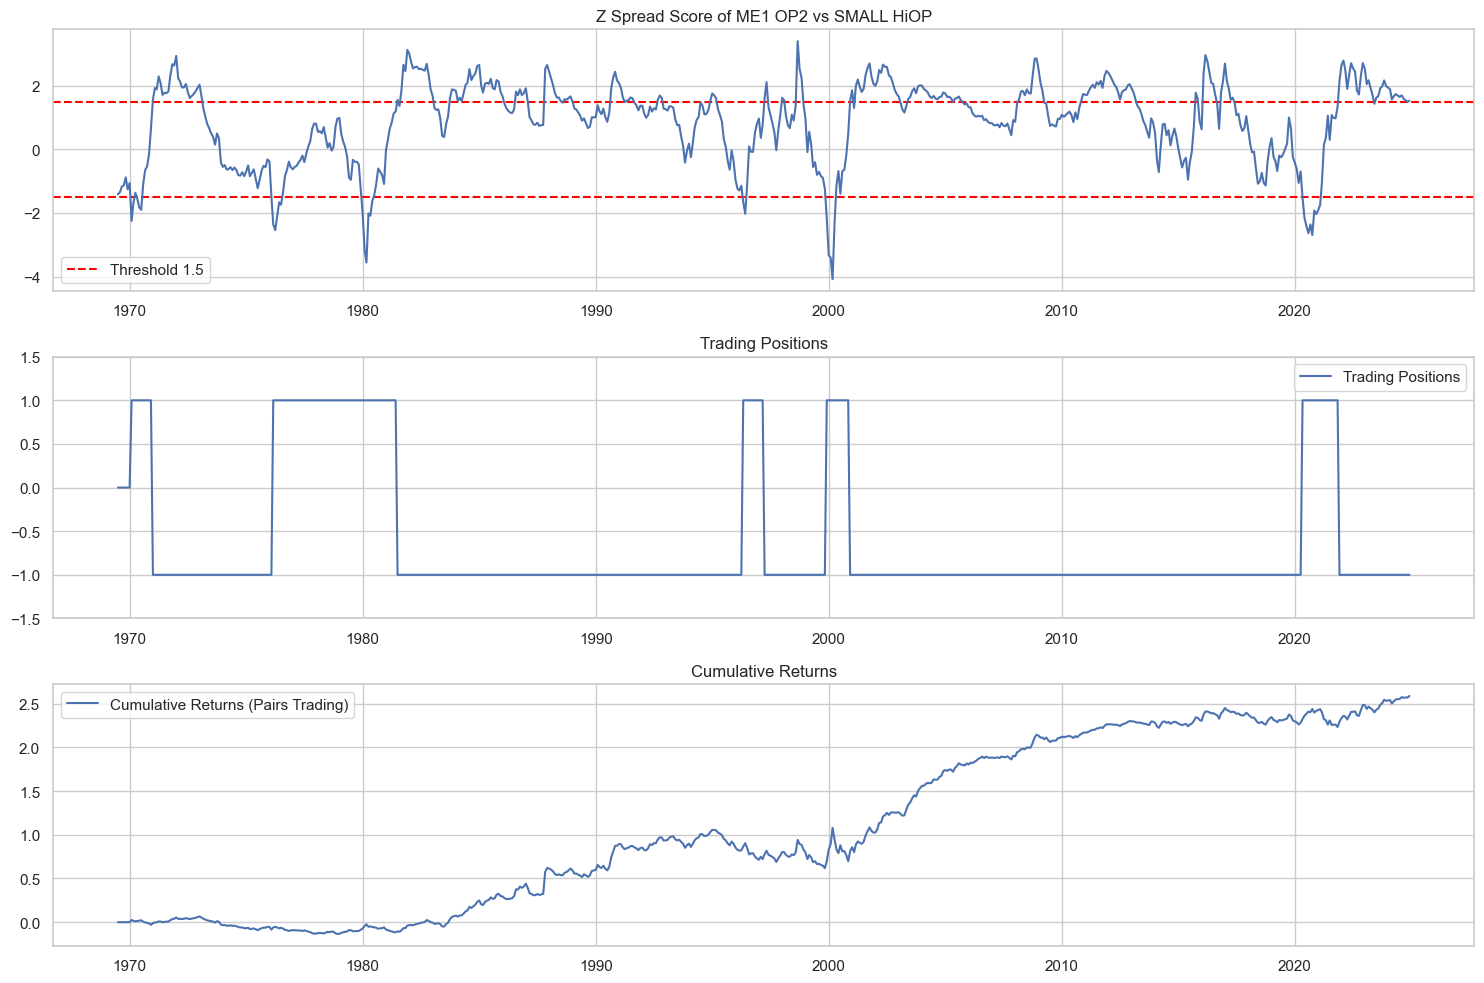

In [28]:
spread_plot = pd.DataFrame({'z_score': spread_df}, index=price_df.index[window_size:])


plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.axhline(y=1.5, color='red', linestyle='--', linewidth=1.5, label='Threshold 1.5')
plt.axhline(y=-1.5, color='red', linestyle='--', linewidth=1.5)
plt.plot(spread_plot.index,spread_plot['z_score'])
plt.title('Z Spread Score of ME1 OP2 vs SMALL HiOP')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(df_rolling['position'], label='Trading Positions')
plt.title('Trading Positions')
plt.ylim([-1.5, 1.5])
plt.legend()
plt.grid(True)

# 3rd subplot: Cumulative Returns
plt.subplot(3, 1, 3)
plt.plot(df_rolling['cumret'], label='Cumulative Returns (Pairs Trading)')
plt.title('Cumulative Returns')
plt.legend()
plt.grid(True)

# # Show the plots
plt.tight_layout()
plt.show()

# Mean Variance Analysis

In [228]:
mu = df.mean() * 12

# Calculate the covariance matrix for the portfolio returns
cov_matrix = df.cov() * 12

mu, cov_matrix

(SMALL LoOP    0.116605
 ME1 OP2       0.146437
 SMALL HiOP    0.154605
 BIG LoOP      0.094760
 ME2 OP2       0.109407
 BIG HiOP      0.125139
 dtype: float64,
             SMALL LoOP   ME1 OP2  SMALL HiOP  BIG LoOP   ME2 OP2  BIG HiOP
 SMALL LoOP    0.052234  0.039791    0.044372  0.034825  0.027633  0.026308
 ME1 OP2       0.039791  0.034879    0.038711  0.027790  0.023831  0.022720
 SMALL HiOP    0.044372  0.038711    0.045270  0.031452  0.027132  0.026459
 BIG LoOP      0.034825  0.027790    0.031452  0.031759  0.025059  0.023537
 ME2 OP2       0.027633  0.023831    0.027132  0.025059  0.022847  0.021330
 BIG HiOP      0.026308  0.022720    0.026459  0.023537  0.021330  0.023083)

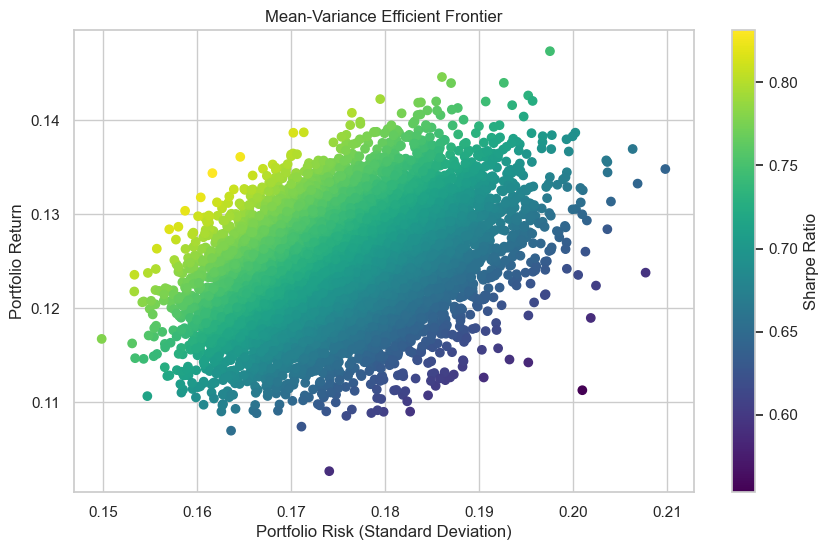

In [220]:
# Simulate random portfolios
num_portfolios = 10000
results = np.zeros((3, num_portfolios))  # Store returns, volatility, and Sharpe ratios

# Simulate the portfolio weights
for i in range(num_portfolios):
    weights = np.random.random(len(mu))
    weights /= np.sum(weights)  # Normalize weights to sum to 1

    # Portfolio return and volatility (risk)
    portfolio_return = np.sum(weights * mu)
    portfolio_stddev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    
    # Portfolio Sharpe ratio (assuming a risk-free rate of 0)
    sharpe_ratio = portfolio_return / portfolio_stddev if portfolio_stddev != 0 else 0

    # Store the results
    results[0, i] = portfolio_return
    results[1, i] = portfolio_stddev
    results[2, i] = sharpe_ratio

# Convert results to DataFrame for better visualization
results_df = pd.DataFrame(results.T, columns=['Return', 'Risk', 'Sharpe Ratio'])

# Plot the efficient frontier
plt.figure(figsize=(10, 6))
plt.scatter(results_df['Risk'], results_df['Return'], c=results_df['Sharpe Ratio'], cmap='viridis', marker='o')
plt.title('Mean-Variance Efficient Frontier')
plt.xlabel('Portfolio Risk (Standard Deviation)')
plt.ylabel('Portfolio Return')
plt.colorbar(label='Sharpe Ratio')
plt.show()


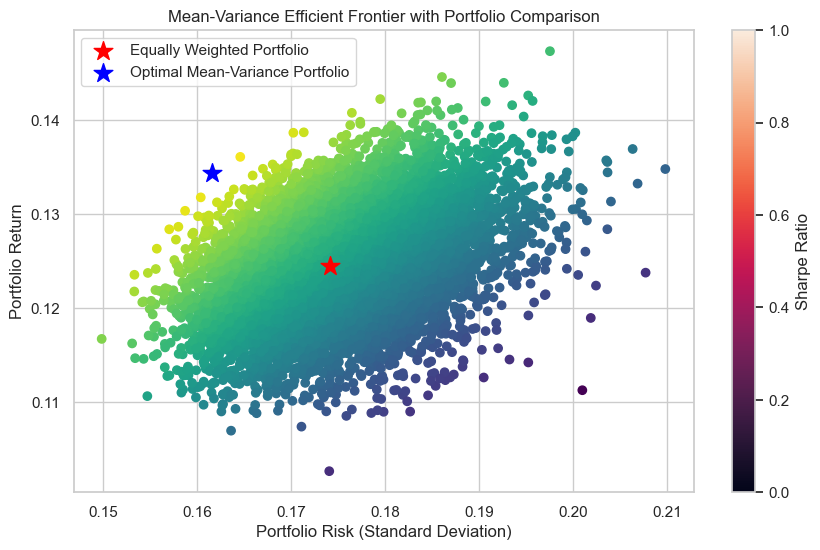

(Return          0.134369
 Risk            0.161625
 Sharpe Ratio    0.831365
 Name: 381, dtype: float64,
 (np.float64(0.1244921680216802), np.float64(0.1741624609682854)))

In [221]:
# Find the portfolio with the highest Sharpe ratio (optimal mean-variance portfolio)
optimal_portfolio = results_df.iloc[results_df['Sharpe Ratio'].idxmax()]

# Calculate the equally weighted portfolio (each weight is 1/6)
equal_weights = np.ones(len(mu)) / len(mu)

# Portfolio return and risk for equally weighted portfolio
equal_weight_return = np.sum(equal_weights * mu)
equal_weight_risk = np.sqrt(np.dot(equal_weights.T, np.dot(cov_matrix, equal_weights)))

# Compare the performance of the optimal portfolio with the equally weighted portfolio
optimal_portfolio_return = optimal_portfolio['Return']
optimal_portfolio_risk = optimal_portfolio['Risk']

# Plot comparison of the two portfolios
plt.figure(figsize=(10, 6))
plt.scatter(results_df['Risk'], results_df['Return'], c=results_df['Sharpe Ratio'], cmap='viridis', marker='o')
plt.scatter(equal_weight_risk, equal_weight_return, color='red', marker='*', s=200, label='Equally Weighted Portfolio')
plt.scatter(optimal_portfolio_risk, optimal_portfolio_return, color='blue', marker='*', s=200, label='Optimal Mean-Variance Portfolio')
plt.title('Mean-Variance Efficient Frontier with Portfolio Comparison')
plt.xlabel('Portfolio Risk (Standard Deviation)')
plt.ylabel('Portfolio Return')
plt.colorbar(label='Sharpe Ratio')
plt.legend()
plt.show()

optimal_portfolio, (equal_weight_return, equal_weight_risk)


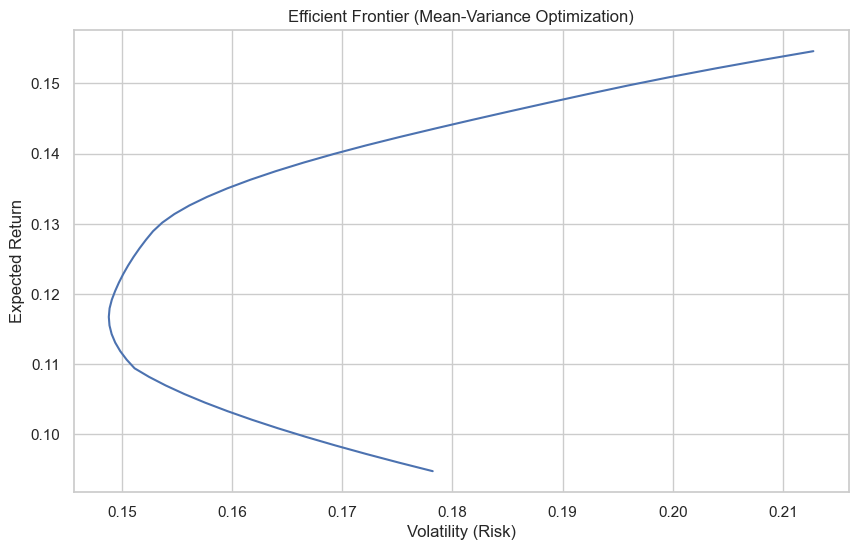

In [ ]:
from scipy.optimize import minimize

num_portfolios = len(df.columns)

def portfolio_return(weights, mu):
    return np.sum(weights * mu)

def portfolio_volatility(weights, cov_matrix):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

# Function for mean-variance optimization (minimizing risk for a given return)
def objective(weights, mu, cov_matrix, target_return):
    return portfolio_volatility(weights, cov_matrix)  # Minimize risk

# Constraints: weights sum to 1 (fully invested portfolio), return target constraint
def constraint(weights, mu, target_return):
    return portfolio_return(weights, mu) - target_return

# Generate a range of portfolio combinations (randomly generated weights for optimization)
target_returns = np.linspace(min(mu), max(mu), 50)
volatilities = []  # List to store volatilities for each target return
weights_list = []  # List to store portfolio weights for each target return

for target_return_value in target_returns:
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},  # Fully invested portfolio
                   {'type': 'eq', 'fun': lambda w: constraint(w, mu, target_return_value)})
    bounds = tuple((0, 1) for _ in range(num_portfolios))  # No short-selling (weights between 0 and 1)
    initial_guess = np.ones(num_portfolios) / num_portfolios  # Equal distribution of weights

    result = minimize(objective, initial_guess, args=(mu, cov_matrix, target_return_value),
                      method='SLSQP', bounds=bounds, constraints=constraints)

    weights_list.append(result.x)
    volatilities.append(result.fun)

plt.figure(figsize=(10, 6))
plt.plot(volatilities, target_returns, 'b-', label='Efficient Frontier')
plt.title('Efficient Frontier (Mean-Variance Optimization)')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.grid(True)
plt.show()


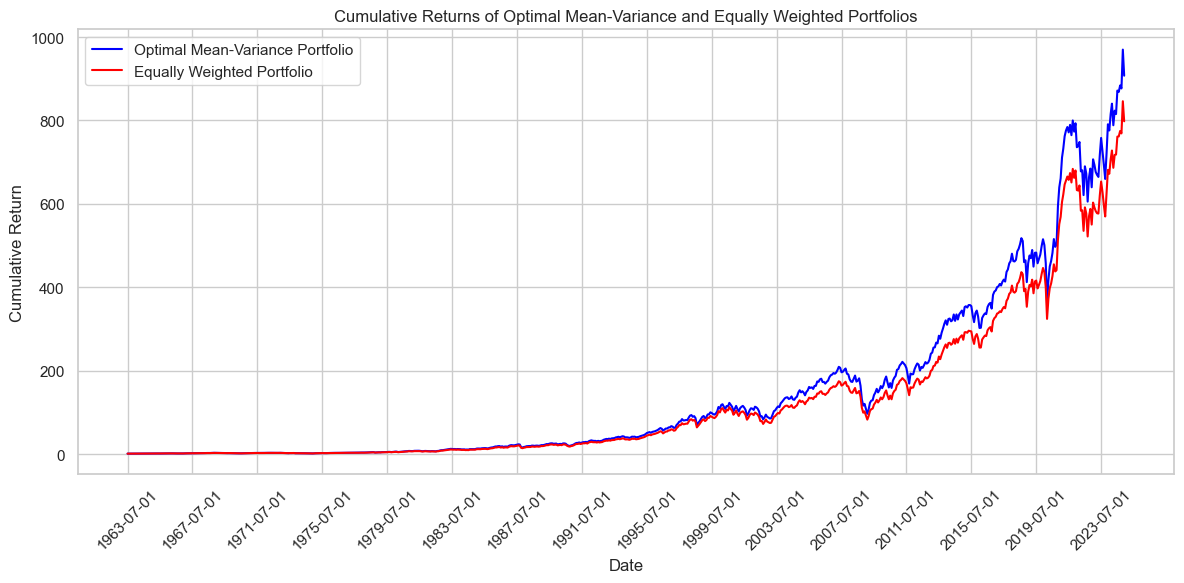

In [253]:
# Extract the optimal weights from the optimal portfolio
optimal_weights = np.random.random(len(mu))
optimal_weights /= np.sum(optimal_weights)  # Normalize the weights to sum to 1

# Calculate the cumulative returns for the optimal portfolio and the equally weighted portfolio
optimal_portfolio_returns = np.dot(df, optimal_weights)
equal_weight_returns = np.dot(df, equal_weights)

# Calculate the cumulative returns
optimal_cumulative_returns = (1 + optimal_portfolio_returns / 100).cumprod()
equal_weight_cumulative_returns = (1 + equal_weight_returns / 100).cumprod()

# Plot the cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(df.index, optimal_cumulative_returns, label='Optimal Mean-Variance Portfolio', color='blue')
plt.plot(df.index, equal_weight_cumulative_returns, label='Equally Weighted Portfolio', color='red')
plt.title('Cumulative Returns of Optimal Mean-Variance and Equally Weighted Portfolios')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.xticks(df.index[::48], rotation=45)  # Show every 48th date for readability
plt.tight_layout()
plt.show()
